# Deep Analysis: LLM IaC Generation Errors & DevOps Simulation
This notebook performs a multi-model evaluation of Infrastructure-as-Code (IaC) generation. It links scenario outcomes (`results.csv`) with the granular step-by-step failures (`error_history.csv`) to extract insights into *why* LLMs fail and *what they lack*.

**Key Analytical Goals:**
1. Cross-Model Performance (Pass@1 vs. Iterative Success)
2. Pipeline Stage Bottlenecks (Syntax vs. Live Deployment)
3. Model Stubbornness (Failing to resolve the exact same error across iterations)
4. Resource Vulnerability (Which cloud resources are hardest to generate?)
5. Error Taxonomy Deep Dive (Factual Incorrectness vs. Incompleteness vs. CRF)
6. Self-Healing Efficiency (Iterations-to-Resolution per Error Type)
7. Identification of Research Gaps

In [ ]:
# pip install 'plotly[kaleido]'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import glob
import ast
import re
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# ── Model key resolver (filename-first, llm_model fallback) ──────────────────
_KEY_PATTERNS = [
    ('claude-3-5',        r'claude-3-5'),
    ('claude-3-7',        r'claude-3-7'),
    ('o3-mini',           r'o3-mini'),
    ('gpt-4o',            r'gpt-4o|gpt'),
    ('deepseek-reasoner', r'deepseek-reasoner'),
    ('deepseek-chat',     r'deepseek-chat'),
    # ('20260302',          r'20260302'),
    ('trinity-sec',         r'cgo-sec'),
    ('trinity-cgo',         r'cgo-local'),
    ('trinity-cgo',               r'cgo'),
    ('trinity-scot',              r'scot'),
    ('trinity-cot',               r'cot'),
    ('trinity-tdd',               r'tdd'),
    ('trinity-baseline',          r'baseline'),
]

def _match_patterns(text: str) -> str | None:
    """Return first matching model key for a given string, or None."""
    t = str(text).lower()
    for key, pattern in _KEY_PATTERNS:
        if re.search(pattern, t):
            return key
    return None

def model_key_from_filename(filepath: str) -> str | None:
    """Try to resolve a model key from the file path alone."""
    # Use the full path so folder names like 'baseline', 'cot' also match
    return _match_patterns(filepath)

def model_key_from_llm_model(llm_model_value: str) -> str:
    """Resolve model key from the llm_model column value (fallback)."""
    result = _match_patterns(llm_model_value)
    if result:
        return result
    # Last-resort: return the raw value so nothing silently becomes 'unknown'
    return str(llm_model_value)

def resolve_model_key(filepath: str, llm_model_value: str = None) -> str:
    """
    Primary:  derive key from filepath (stable, you control naming).
    Fallback: derive key from llm_model column value.
    """
    key = model_key_from_filename(filepath)
    if key:
        return key
    if llm_model_value is not None:
        return model_key_from_llm_model(llm_model_value)
    # Absolute last resort: clean stem from filename
    stem = os.path.splitext(os.path.basename(filepath))[0]
    return stem.split('_error')[0].split('_results')[0]

# ── 1. Load Results Data ──────────────────────────────────────────────────────
result_files = [
    # './result/iterative_claude-3-5-sonnet-20241022_results.csv',
    # './result/iterative_claude-3-7-sonnet-20250219_results.csv',
    # './result/iterative_o3-mini_results.csv',
    # './result/iterative_gpt-4o_results.csv',
    # './result/iterative_deepseek-reasoner_results.csv',
    # './result/iterative_deepseek-chat_results.csv'
    # './result/arcee-ai/trinity-large-preview/free_results-20260304.csv',
    './result/arcee-ai/trinity-large-preview/free_results-baseline.csv',
    './result/arcee-ai/trinity-large-preview/free_results-cot.csv',
    # './result/arcee-ai/trinity-large-preview/free_results-cgo.csv',
    './result/arcee-ai/trinity-large-preview/free_results-cgo-local.csv',
    './result/arcee-ai/trinity-large-preview/free_results-cgo-sec.csv',
    # './result/arcee-ai/trinity-large-preview/free_results-scot.csv',
    # './result/arcee-ai/trinity-large-preview/free_results-tdd.csv'
]

results_dfs = []
for fp in result_files:
    tmp = pd.read_csv(fp)
    # Results files: filename is always available and reliable
    tmp['model_key'] = resolve_model_key(fp)
    tmp['source_file'] = os.path.basename(fp)
    results_dfs.append(tmp)

results_df = pd.concat(results_dfs, ignore_index=True)
results_df['success'] = results_df['success'].astype(str).str.upper() == 'TRUE'

# ── 2. Load Error History Data ────────────────────────────────────────────────
history_files = [
    # './error_tracking/claude-3-5-sonnet-20241022_error_history.csv',
    # './error_tracking/claude-3-7-sonnet-20250219_error_history.csv',
    # './error_tracking/o3-mini_error_history.csv',
    # './error_tracking/gpt-4o_error_history.csv',
    # './error_tracking/deepseek-reasoner_error_history.csv',
    # './error_tracking/deepseek-chat_error_history.csv'
    # './error_tracking/arcee-ai/trinity-large-preview/free_error_history-20260302.csv',
    './error_tracking/arcee-ai/trinity-large-preview/free_error_history-baseline.csv',
    './error_tracking/arcee-ai/trinity-large-preview/free_error_history-cot.csv',
    # './error_tracking/arcee-ai/trinity-large-preview/free_error_history-cgo.csv',
    './error_tracking/arcee-ai/trinity-large-preview/free_error_history-cgo-local.csv',
    './error_tracking/arcee-ai/trinity-large-preview/free_error_history-cgo-sec.csv',
    # './error_tracking/arcee-ai/trinity-large-preview/free_error_history-scot.csv',
    # './error_tracking/arcee-ai/trinity-large-preview/free_error_history-tdd.csv'
]

history_dfs = []
for fp in history_files:
    print(f"Loading: {fp}")
    tmp = pd.read_csv(fp, low_memory=False)
    tmp['source_file'] = os.path.basename(fp)
    # History files: try filename first, fall back to llm_model column
    llm_col = tmp['llm_model'] if 'llm_model' in tmp.columns else pd.Series([None] * len(tmp))
    tmp['model_key'] = [
        resolve_model_key(fp, lm)
        for lm in llm_col
    ]
    history_dfs.append(tmp)

history_df = pd.concat(history_dfs, ignore_index=True)

# ── 3. Data Cleaning ──────────────────────────────────────────────────────────
history_df['row_number'] = pd.to_numeric(history_df['row_number'], errors='coerce')
results_df['row_number'] = pd.to_numeric(results_df['row_number'], errors='coerce')

# ── 4. Sanity check ───────────────────────────────────────────────────────────
print(f"\nLoaded {len(results_df)} total scenario results across {results_df['model_key'].nunique()} models.")
print(f"Loaded {len(history_df)} granular error events.")
print("\nresults_df model_key values:", sorted(results_df['model_key'].unique()))
print("history_df model_key values:", sorted(history_df['model_key'].unique()))

# Warn if any raw llm_model values leaked through (no pattern matched)
known_keys = {k for k, _ in _KEY_PATTERNS}
leaked = history_df[~history_df['model_key'].isin(known_keys)]['model_key'].unique()
if len(leaked):
    print(f"\n⚠ Unrecognised model_key values (review _KEY_PATTERNS): {leaked}")
else:
    print("\n✓ All model_key values resolved cleanly.")

# 4. Load User Intent Data
intent_files = [
    './user_intent/user_intent_trinity-baseline_results.csv',
    './user_intent/user_intent_trinity-cot_results.csv',
    './user_intent/user_intent_trinity-cgo_results.csv',
    # './user_intent/user_intent_trinity-cgo_results.csv',
]

intent_df = pd.DataFrame()
for file in intent_files:
    temp_df = pd.read_csv(file)
    model_key = file.replace('./user_intent/user_intent_', '').replace('_results.csv', '')
    temp_df['model_key'] = resolve_model_key(file)
    intent_df = pd.concat([intent_df, temp_df], ignore_index=True)

# Normalise types
intent_df['row_number'] = pd.to_numeric(intent_df['row_number'], errors='coerce')
intent_df['pass_user_intent'] = intent_df['pass_user_intent'].astype(str).str.upper() == 'TRUE'
intent_df['coverage_percentage'] = pd.to_numeric(intent_df['coverage_percentage'], errors='coerce')
intent_df['accuracy_percentage']  = pd.to_numeric(intent_df['accuracy_percentage'],  errors='coerce')

print(f"Loaded {len(intent_df)} user intent rows across {intent_df['model_key'].nunique()} model keys.")



Loading: ./error_tracking/arcee-ai/trinity-large-preview/free_error_history-baseline.csv
Loading: ./error_tracking/arcee-ai/trinity-large-preview/free_error_history-cot.csv
Loading: ./error_tracking/arcee-ai/trinity-large-preview/free_error_history-cgo-local.csv
Loading: ./error_tracking/arcee-ai/trinity-large-preview/free_error_history-cgo-sec.csv

Loaded 599 total scenario results across 4 models.
Loaded 6494 granular error events.

results_df model_key values: ['trinity-baseline', 'trinity-cgo', 'trinity-cot', 'trinity-sec']
history_df model_key values: ['trinity-baseline', 'trinity-cgo', 'trinity-cot', 'trinity-sec']

✓ All model_key values resolved cleanly.
Loaded 152 user intent rows across 3 model keys.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL: Deduplicate error history — unique by (row_number, iteration_number)
#       Aggregate error_messages and resource_names into pipe-separated strings
# ══════════════════════════════════════════════════════════════════════════════

def aggregate_error_history(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ('error_message', 'resource_name'):
        df[col] = (
            df[col].astype(str)
                   .str.strip()
                   .replace({'nan': pd.NA, 'N/A': pd.NA, '': pd.NA, 'None': pd.NA})
        )

    concat_cols = ['error_message', 'resource_name']
    group_keys  = ['model_key', 'row_number', 'iteration_number']
    first_cols  = [c for c in df.columns if c not in concat_cols + group_keys]

    # ── FIX: removed the broken placeholder dict comprehension ───────────────
    # The lambda must use pd.Series(x).dropna() because groupby passes a
    # numpy array to named-agg lambdas, not a pandas Series
    agg_spec = {
        c: (c, lambda x: ' | '.join(pd.Series(x).dropna().astype(str).unique()))
        for c in concat_cols
    }
    agg_spec.update({c: (c, 'first') for c in first_cols})

    deduped = (
        df.groupby(group_keys, sort=True, dropna=False)
          .agg(**agg_spec)
          .reset_index()
    )

    for col in concat_cols:
        deduped[col] = deduped[col].replace('', pd.NA)

    print(f"  Before dedup : {len(df):,} rows")
    print(f"  After dedup  : {len(deduped):,} rows  "
          f"({len(df) - len(deduped):,} duplicate event rows collapsed)")
    print(f"  Unique tasks : {deduped['row_number'].nunique()}")
    print(f"  Unique iters : {deduped.groupby('row_number')['iteration_number'].max().mean():.1f} avg iters/task")

    return deduped


print("── Deduplicating error history ──")
history_df_raw   = history_df.copy()          # keep original if needed
history_df       = aggregate_error_history(history_df)

── Deduplicating error history ──
  Before dedup : 6,494 rows
  After dedup  : 2,134 rows  (4,360 duplicate event rows collapsed)
  Unique tasks : 147
  Unique iters : 6.8 avg iters/task


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL: Classify LocalStack-caused errors; tag results as contaminated/clean
#       Returns: history_df (with ls_category), results_df (with eval flags)
# ══════════════════════════════════════════════════════════════════════════════

import re

# ── Pattern registry ──────────────────────────────────────────────────────────
# Each entry: (category_id, label, regex, fixable_by_model, root_config_cause)
LS_REGISTRY = [
    (
        'LS-1',
        'Lambda: Docker unavailable',
        r'Error while creating lambda: Docker not available',
        False,
        'LAMBDA_REMOTE_DOCKER=false + podman socket; LocalStack Lambda still resolves Docker daemon'
    ),
    (
        'LS-2',
        'EC2: Stale/hardcoded AMI ID',
        r'InvalidAMIID\.NotFound|ami-[0-9a-z]+ does not exist',
        False,
        'EC2_VM_MANAGER=mock; mock manager rejects all real AMI IDs'
    ),
    (
        'LS-3',
        'Resource already exists (state leak)',
        r'already exists|EntityAlreadyExists|ResourceInUseException|ResourceConflictException|ResourceAlreadyExistsException',
        False,
        'PERSISTENCE=0; prior failed stack resources not cleaned up within session'
    ),
    (
        'LS-4',
        'Service not implemented / internal error',
        r'InternalError.*exception while calling|Expecting property name enclosed in double quotes'
        r"|'parentId'|'DeliveryStreamName'|Parameter validation failed",
        False,
        'LocalStack partial emulation: resource-groups JSON parser bug; Firehose/API GW not fully implemented'
    ),
    (
        'LS-5',
        'Pre-requisite resource missing (not seeded)',
        r'ResourceNotFoundException|does not exist in .us-east-1|'
        r'Resource type .* does not exist in',
        False,
        'PERSISTENCE=0 + no seed scripts; Timestream DB, EventBridge bus, ECR policy must pre-exist'
    ),
    (
        'LS-6',
        'AWS-managed policy not available',
        r'NoSuchEntity.*AttachRolePolicy.*arn:aws:iam::aws:policy',
        'partial',   # model could inline policy instead
        'LocalStack does not pre-load all AWS-managed policies'
    ),
    (
        'LS-7',
        'VPC/Subnet ID invalid or missing',
        r'InvalidVPCId|InvalidSubnet|vpcConfig\.subnetIds.*failed'
        r'|Parameters:.*VPCId.*must have values',
        'partial',
        'LocalStack default VPC not always created; real subnet IDs invalid in LocalStack'
    ),
    (
        'LS-8',
        'Cognito MFA not supported',
        r'Define at least one MFA configuration',
        False,
        'LocalStack Cognito MFA emulation incomplete'
    ),
    (
        'LS-9',
        'Lambda S3 code bucket missing',
        r'NoSuchBucket|S3 Error Code: NoSuchBucket',
        False,
        'Lambda CodeUri references S3 bucket not seeded in LocalStack'
    ),
    (
        'LS-10',
        'Waiter timeout (slow emulation)',
        r'Waiter \w+ failed|Max attempts exceeded',
        False,
        'LAMBDA_RUNTIME_ENVIRONMENT_TIMEOUT=60 too short for RDS/slow services'
    ),
    (
        'LS-11',
        'Env parameter not supplied',
        r'Parameter (?:AMI|OAuthToken|\w+) should either have input value'
        r'|Parameters:.*(?:OAuthToken|AMI).*must have values',
        'partial',
        'Test harness does not inject env-specific parameters (AMI, OAuth tokens)'
    ),
    (
        'LS-12',
        'IAM root ARN quirk (000000000000)',
        r'arn:aws:iam::000000000000:root not found',
        False,
        'LocalStack uses account 000000000000; :root principal not resolvable'
    ),
    (
        'LS-13',
        'MalformedPolicyDocument',
        r'MalformedPolicyDocument',
        False,
        'LocalStack IAM strict policy parser rejects documents valid in real AWS'
    ),
]

# Pre-compile for performance
LS_COMPILED = [
    (cat_id, label, re.compile(pattern, re.IGNORECASE), fixable, cause)
    for cat_id, label, pattern, fixable, cause in LS_REGISTRY
]

# Unrecoverable = model cannot fix regardless of iterations
LS_UNRECOVERABLE_IDS = {'LS-1', 'LS-2', 'LS-3', 'LS-4', 'LS-5',
                         'LS-8', 'LS-9', 'LS-10', 'LS-12', 'LS-13'}
LS_PARTIAL_IDS       = {'LS-6', 'LS-7', 'LS-11'}


def classify_ls_error(msg: str) -> tuple[str | None, str | None]:
    """
    Returns (category_id, full_label) or (None, None) if not LS-caused.
    When aggregated messages contain multiple errors (pipe-separated),
    the MOST SEVERE (earliest in LS_REGISTRY) match wins.
    """
    if not msg or str(msg).strip() in ('nan', 'N/A', 'None', ''):
        return None, None
    for cat_id, label, pattern, _, _ in LS_COMPILED:
        if pattern.search(str(msg)):
            return cat_id, f"{cat_id} · {label}"
    return None, None   # genuine LLM error or unclassified


# ── Apply to history ──────────────────────────────────────────────────────────
history_df[['ls_id', 'ls_category']] = (
    history_df['error_message']
    .apply(lambda m: pd.Series(classify_ls_error(m)))
)
history_df['is_ls_error']          = history_df['ls_id'].notna()
history_df['ls_recoverable']       = history_df['ls_id'].apply(
    lambda x: False if x in LS_UNRECOVERABLE_IDS
              else ('partial' if x in LS_PARTIAL_IDS else None)
)

# ── Build contaminated task sets ──────────────────────────────────────────────
_ls_hist = history_df[history_df['is_ls_error']]

unrecoverable_rows = set(
    _ls_hist[_ls_hist['ls_id'].isin(LS_UNRECOVERABLE_IDS)]
    ['row_number'].dropna().astype(int)
)
partial_rows = set(
    _ls_hist[_ls_hist['ls_id'].isin(LS_PARTIAL_IDS)]
    ['row_number'].dropna().astype(int)
) - unrecoverable_rows   # partial only if NOT also unrecoverable

# ── Tag results_df ────────────────────────────────────────────────────────────
results_df['row_number'] = pd.to_numeric(results_df['row_number'], errors='coerce')

results_df['eval_contaminated'] = (
    results_df['row_number'].astype('Int64').isin(unrecoverable_rows)
)
results_df['eval_partial_ls'] = (
    results_df['row_number'].astype('Int64').isin(partial_rows)
)
results_df['eval_clean'] = (
    ~results_df['eval_contaminated'] & ~results_df['eval_partial_ls']
)

# ── Clean subsets for downstream analysis ─────────────────────────────────────
history_clean  = history_df[~history_df['row_number'].astype('Int64').isin(unrecoverable_rows)].copy()
results_clean  = results_df[results_df['eval_clean']].copy()

# ── Report ────────────────────────────────────────────────────────────────────
print("── LocalStack Classification Report ──\n")
print(f"  history_df rows total          : {len(history_df):,}")
print(f"  LS-caused events               : {history_df['is_ls_error'].sum():,} "
      f"({history_df['is_ls_error'].mean()*100:.1f}%)")
print(f"\n  LS category breakdown:")
for row in (
    history_df[history_df['is_ls_error']]
    .groupby('ls_category')
    .size().sort_values(ascending=False)
    .reset_index(name='count').itertuples()
):
    print(f"    {row.count:4d}  {row.ls_category}")

print(f"\n  results_df rows total          : {len(results_df):,}")
print(f"  Unrecoverable-contaminated rows: {results_df['eval_contaminated'].sum()} "
      f"({results_df['eval_contaminated'].mean()*100:.1f}%)")
print(f"  Partial-LS rows                : {results_df['eval_partial_ls'].sum()} "
      f"({results_df['eval_partial_ls'].mean()*100:.1f}%)")
print(f"  Clean eval rows                : {results_df['eval_clean'].sum()} "
      f"({results_df['eval_clean'].mean()*100:.1f}%)")

for run in results_df['model_key'].unique():
    r    = results_df[results_df['model_key'] == run]
    rc   = r[r['eval_clean']]
    raw  = r['success'].mean() * 100
    adj  = rc['success'].mean() * 100
    print(f"\n  [{run}] raw success={raw:.1f}%  "
          f"adjusted (clean only)={adj:.1f}%  "
          f"(n_clean={len(rc)}, n_excl={len(r)-len(rc)})")


## 1. Overall Pass Rates and Pass@k
If an LLM requires 12 iterations to deploy a database, is it truly autonomous? Here we compare the zero-shot (Pass@1) capabilities vs the final success rate after exhausting all feedback attempts.

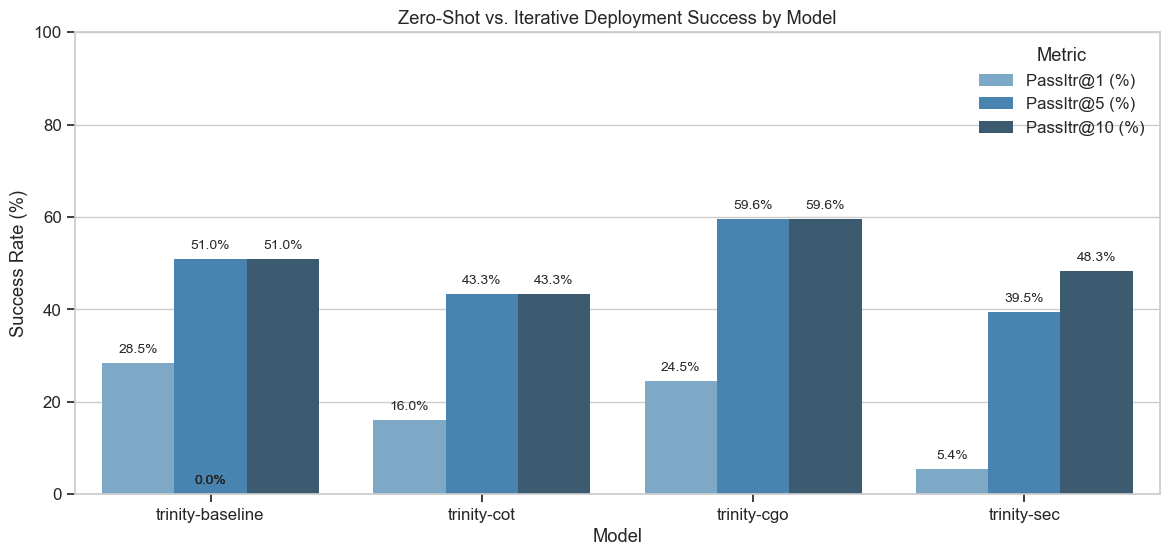

In [11]:
plt.figure(figsize=(14, 6))

metrics = []
for model in results_df['model_key'].unique():
    model_data = results_df[results_df['model_key'] == model]
    total = len(model_data)
    if total == 0: continue
    overall_pass = model_data['success'].sum()
    pass_at_1 = len(model_data[(model_data['success'] == True) & (model_data['total_iterations'] == 1)])
    pass_at_2 = len(model_data[(model_data['success'] == True) & (model_data['total_iterations'] <= 2)])
    pass_at_3 = len(model_data[(model_data['success'] == True) & (model_data['total_iterations'] <= 3)])
    pass_at_4 = len(model_data[(model_data['success'] == True) & (model_data['total_iterations'] <= 4)])
    pass_at_5 = len(model_data[(model_data['success'] == True) & (model_data['total_iterations'] <= 5)])
    pass_at_10 = len(model_data[(model_data['success'] == True) & (model_data['total_iterations'] <= 10)])
    metrics.append({
        'Model': model,
        'PassItr@1 (%)': (pass_at_1 / total) * 100,
        # 'Pass@2 (%)': (pass_at_2 / total) * 100,
        # 'Pass@3 (%)': (pass_at_3 / total) * 100,
        # 'Pass@4 (%)': (pass_at_4 / total) * 100,
        'PassItr@5 (%)': (pass_at_5 / total) * 100,
        'PassItr@10 (%)': (pass_at_10 / total) * 100
        # 'Overall Pass (%)': (overall_pass / total) * 100
    })

metrics_df = pd.DataFrame(metrics).melt(id_vars='Model', var_name='Metric', value_name='Success Rate (%)')

sns.barplot(data=metrics_df, x='Model', y='Success Rate (%)', hue='Metric', palette='Blues_d')
plt.title('Zero-Shot vs. Iterative Deployment Success by Model')
plt.ylim(0, 100)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.savefig('plots/pass_rate_models.png', dpi=150, bbox_inches='tight')  # ← before show()
plt.show()

difficulty
1    134
2    199
3     96
4     64
5    106
Name: count, dtype: int64

Unresolved (-1): 0


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_19931/3763607134.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


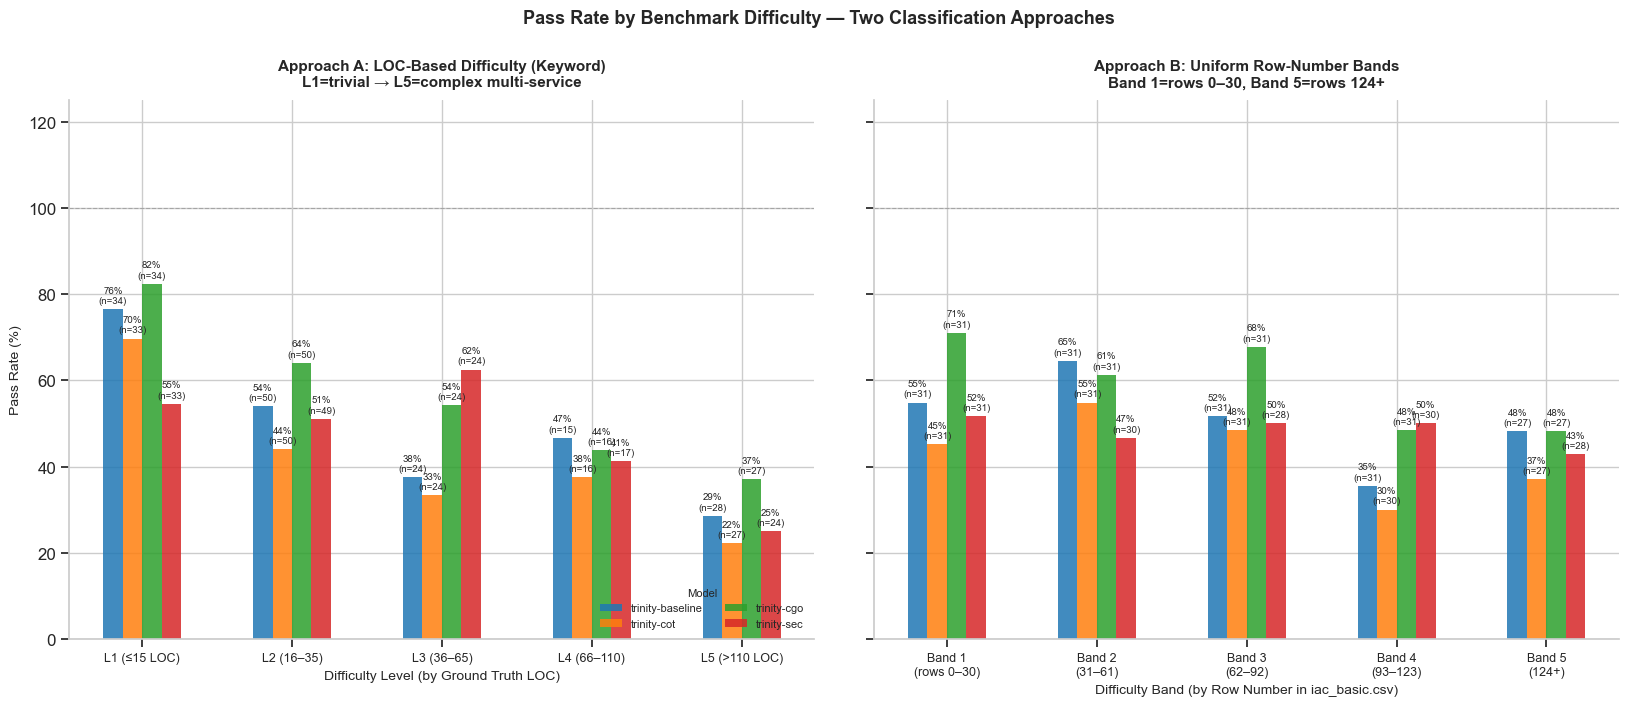


── Approach A: LOC-Based Difficulty (avg across models) ──
               avg_pass_rate  total_tasks
L1 (≤15 LOC)            70.8          134
L2 (16–35)              53.3          199
L3 (36–65)              46.9           96
L4 (66–110)             42.3           64
L5 (>110 LOC)           28.2          106

── Approach B: Uniform Row Bands (avg across models) ──
                     avg_pass_rate  total_tasks
Band 1\n(rows 0–30)           55.6          124
Band 2\n(31–61)               56.8          123
Band 3\n(62–92)               54.4          121
Band 4\n(93–123)              41.0          122
Band 5\n(124+)                44.0          109


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: Pass Rate by Benchmark Difficulty — Two Approaches
#   Approach A: LOC-based difficulty via ground_truth filename keywords (L1–L5)
#   Approach B: Uniform row-number bands (rows 0-30, 31-60, 61-90, 91-120, 121+)
# ═══════════════════════════════════════════════════════════════════════════════
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Approach A: Difficulty assignment from ground truth LoC + resources + parameters ──────
import os
import yaml
import pandas as pd

# ── Step 1: Build difficulty lookup from ground_truth_path ────────────────────
# ground_truth_path format: "groud_truth\template\sqs_easy.yaml"  (Windows paths, typo intentional)
# Resolve to local filesystem using os.path to handle cross-platform separators

GROUND_TRUTH_BASE = './Data/groud_truth/template/'  # <-- match the typo from your data

def get_difficulty_from_path(raw_path: str) -> int:
    """
    Assigns DPIaC-Eval difficulty level (Table 1, IaCGen paper) based on:
      - LoC (non-empty, non-comment lines)
      - Resource count
      - Parameter count

    Level 1: LoC<=50,  resources<=2,  params<=2
    Level 2: LoC<=100, resources<=4,  params<=5
    Level 3: LoC<=150, resources<=6,  params<=9
    Level 4: LoC<=200, resources<=12, params<=14
    Level 5: else
    """
    # ── Guard: NaN, None, or non-string values (failed rows have empty path) ──
    if not isinstance(raw_path, str) or not raw_path.strip():
        return -1
    # Normalise Windows backslashes → local OS separator, then take basename only
    filename  = os.path.basename(raw_path.replace('\\', '/'))
    full_path = os.path.join(GROUND_TRUTH_BASE, filename)

    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            lines   = f.readlines()
        loc     = len([l for l in lines if l.strip() and not l.strip().startswith('#')])
        # content = yaml.safe_load(''.join(lines)) or {}
    except FileNotFoundError:
        print(f"[WARN] Not found: {full_path}")
        return -1
    except yaml.YAMLError as e:
        print(f"[WARN] YAML parse error in {filename}: {e}")
        return -1

    # resources  = len(content.get('Resources',  {}) or {})
    # parameters = len(content.get('Parameters', {}) or {})

    # DPIaC-Eval Table 1 thresholds — all three conditions must hold for L1-L4
    # if   loc <= 50  and resources <= 2  and parameters <= 2:  return 1
    # elif loc <= 100 and resources <= 4  and parameters <= 5:  return 2
    # elif loc <= 150 and resources <= 6  and parameters <= 9:  return 3
    # elif loc <= 200 and resources <= 12 and parameters <= 14: return 4
    if   loc <= 50 :  return 1
    elif loc <= 100:  return 2
    elif loc <= 150:  return 3
    elif loc <= 200: return 4
    else:            return 5


# ── Step 2: Apply to results_df (run once, reuse across cells) ────────────────
results_df['difficulty'] = results_df['ground_truth_path'].apply(get_difficulty_from_path)

# Sanity check — should show 1–5 only, no -1
print(results_df['difficulty'].value_counts().sort_index())
print(f"\nUnresolved (-1): {(results_df['difficulty'] == -1).sum()}")

def get_difficulty_uniform(row_number, band_size=31):
    """Assign difficulty level by uniform row-number bands."""
    if pd.isna(row_number):
        return None
    r = int(row_number)
    if r <= 30:   return 1   # rows  0–30
    if r <= 61:   return 2   # rows 31–61
    if r <= 92:   return 3   # rows 62–92
    if r <= 123:  return 4   # rows 93–123
    return 5                  # rows 124+

results_df['difficulty_uni'] = results_df['row_number'].apply(get_difficulty_uniform)

# ── Shared helpers ─────────────────────────────────────────────────────────────
# MODELS       = results_df['model_key'].unique().tolist()
# MODELS       = ['trinity-baseline', 'trinity-cot', 'trinity-scot', 'trinity-cgo', 'trinity-tdd']
MODELS       = ['trinity-baseline', 'trinity-cot', 'trinity-cgo', 'trinity-sec']
# MODELS       = ['claude-3-5', 'claude-3-7', 'deepseek-chat', 'deepseek-reasoner', 'gpt-4o', 'o3-mini']
LEVELS       = [1, 2, 3, 4, 5]
COLORS       = plt.cm.tab10.colors
BAR_WIDTH    = 0.13

KW_LABELS  = ['L1 (≤15 LOC)', 'L2 (16–35)', 'L3 (36–65)',
              'L4 (66–110)', 'L5 (>110 LOC)']
UNI_LABELS = ['Band 1\n(rows 0–30)', 'Band 2\n(31–61)', 'Band 3\n(62–92)',
              'Band 4\n(93–123)', 'Band 5\n(124+)']

def compute_pass_rates(df, difficulty_col, levels=LEVELS):
    rows = []
    for model in MODELS:
        md = df[df['model_key'] == model]
        for lvl in levels:
            ld    = md[md[difficulty_col] == lvl]
            total = len(ld)
            passed = ld['success'].sum()
            rows.append({
                'model':     model,
                'level':     lvl,
                'total':     total,
                'pass_rate': (passed / total * 100) if total > 0 else 0,
            })
    return pd.DataFrame(rows)

def draw_grouped_bars(ax, diff_df, x_labels, title, legend=True):
    x = np.arange(len(LEVELS))
    for i, model in enumerate(MODELS):
        md    = diff_df[diff_df['model'] == model]
        rates = [md[md['level'] == lvl]['pass_rate'].values[0] for lvl in LEVELS]
        ns    = [int(md[md['level'] == lvl]['total'].values[0]) for lvl in LEVELS]
        offset = x + i * BAR_WIDTH - (len(MODELS) - 1) * BAR_WIDTH / 2
        bars = ax.bar(offset, rates, BAR_WIDTH,
                      label=model, color=COLORS[i], alpha=0.85)
        for bar, rate, n in zip(bars, rates, ns):
            if n > 0:
                ax.annotate(
                    f'{rate:.0f}%\n(n={n})',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7,
                )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_ylabel('Pass Rate (%)', fontsize=10)
    ax.set_ylim(0, 125)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if legend:
        ax.legend(loc='lower right', fontsize=8, ncol=2,
                  framealpha=0.7, title='Model', title_fontsize=8)

# ── Build data for both approaches ────────────────────────────────────────────
df_kw  = compute_pass_rates(results_df, 'difficulty')
df_uni = compute_pass_rates(results_df, 'difficulty_uni')

# ── Plot: two subplots side by side ───────────────────────────────────────────
fig = plt.figure(figsize=(20, 7))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

draw_grouped_bars(ax1, df_kw,  KW_LABELS,
                  'Approach A: LOC-Based Difficulty (Keyword)\nL1=trivial → L5=complex multi-service',
                  legend=True)
draw_grouped_bars(ax2, df_uni, UNI_LABELS,
                  'Approach B: Uniform Row-Number Bands\nBand 1=rows 0–30, Band 5=rows 124+',
                  legend=False)

ax1.set_xlabel('Difficulty Level (by Ground Truth LOC)', fontsize=10)
ax2.set_xlabel('Difficulty Band (by Row Number in iac_basic.csv)', fontsize=10)

# Share y-axis label only on left
ax2.set_ylabel('')
ax2.set_yticklabels([])

fig.suptitle(
    'Pass Rate by Benchmark Difficulty — Two Classification Approaches',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('plots/pass_rate_by_difficulty_both_approaches.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table: side-by-side comparison ────────────────────────────────────
print("\n── Approach A: LOC-Based Difficulty (avg across models) ──")
summary_kw = df_kw.groupby('level').agg(
    avg_pass_rate=('pass_rate', 'mean'),
    total_tasks=('total', 'sum')
).round(1)
summary_kw.index = KW_LABELS
print(summary_kw.to_string())

print("\n── Approach B: Uniform Row Bands (avg across models) ──")
summary_uni = df_uni.groupby('level').agg(
    avg_pass_rate=('pass_rate', 'mean'),
    total_tasks=('total', 'sum')
).round(1)
summary_uni.index = UNI_LABELS
print(summary_uni.to_string())


## 2. Where Do Models Fail? (DevOps Pipeline Stages)
Do models fail because they write invalid YAML/JSON (Syntax), or do they write syntactically valid code that hallucinates non-existent cloud resources (Deployment)?

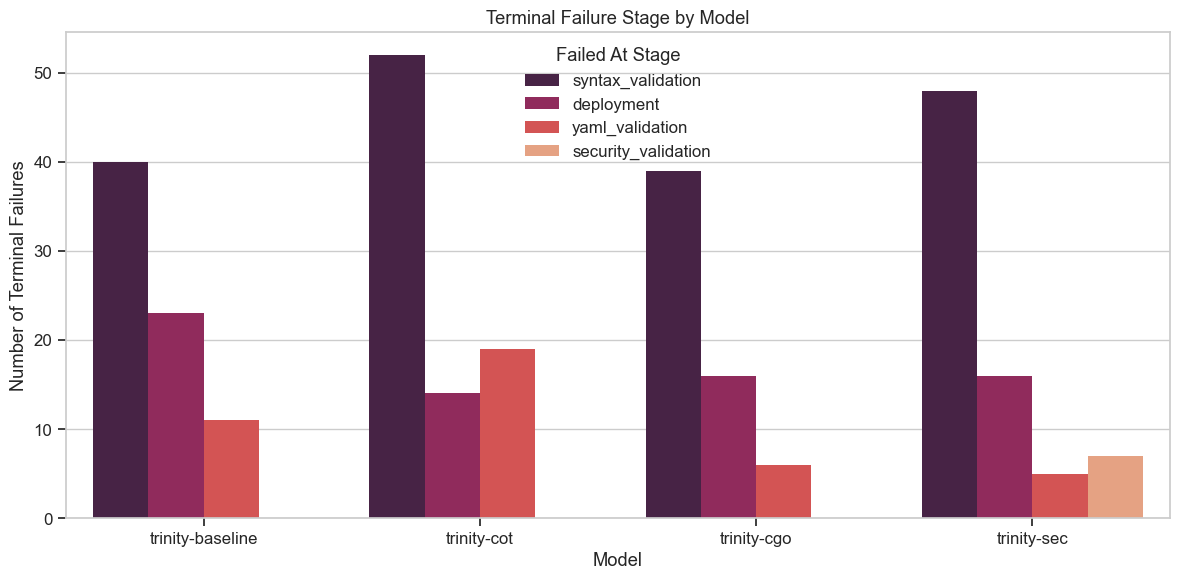

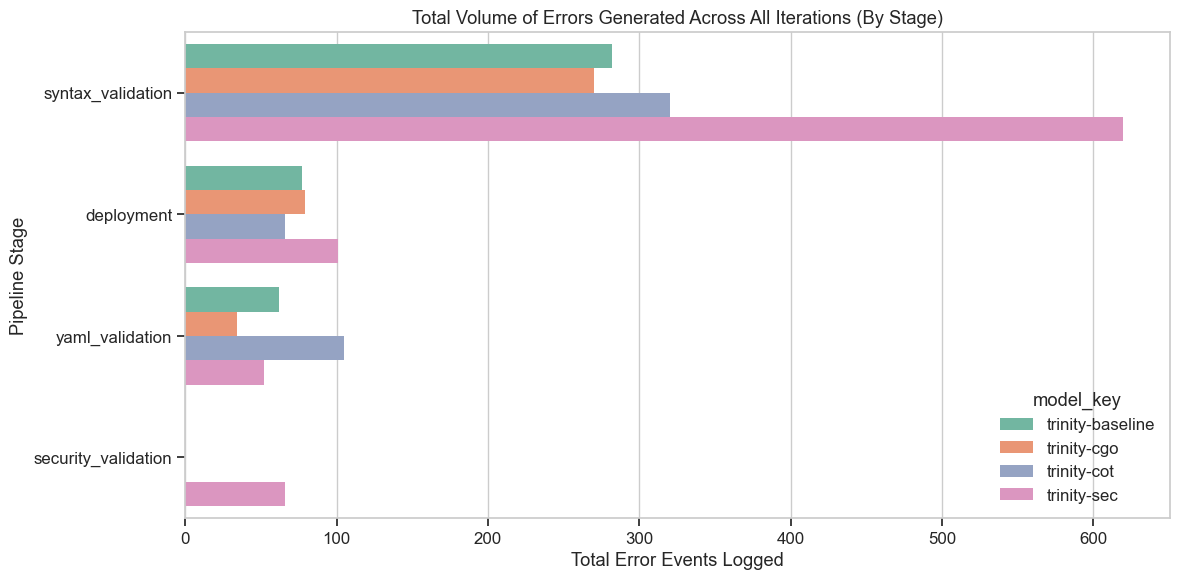

In [17]:
# failed_results = results_df[(results_df['success'] == False) & (results_df['model_key'].isin(['trinity-baseline', 'trinity-cot', 'trinity-scot', 'trinity-cgo', 'trinity-tdd']))].copy()
failed_results = results_df[results_df['success'] == False].copy()
failed_results['failed_at_stage'] = failed_results['failed_at_stage'].fillna('Unknown').astype(str)
failed_results['model'] = failed_results['model_key'].fillna('Unknown').astype(str)

plt.figure(figsize=(12, 6))
sns.countplot(data=failed_results, x='model_key', hue='failed_at_stage', palette='rocket')
plt.title('Terminal Failure Stage by Model')
plt.xlabel('Model')
plt.ylabel('Number of Terminal Failures')
plt.legend(title='Failed At Stage')
plt.tight_layout()
plt.savefig('plots/terminal_failure.png')
plt.show()

# history_df_clean = history_df[(history_df['model_key'].isin(['trinity-baseline', 'trinity-cot', 'trinity-scot', 'trinity-cgo', 'trinity-tdd']))].copy()
history_df_clean = history_df.copy()
history_df_clean['error_stage'] = history_df_clean['error_stage'].fillna('Unknown').astype(str)
history_df_clean['model_key'] = history_df_clean['model_key'].fillna('Unknown').astype(str)

plt.figure(figsize=(12, 6))
sns.countplot(data=history_df_clean, y='error_stage', hue='model_key', palette='Set2')
plt.title('Total Volume of Errors Generated Across All Iterations (By Stage)')
plt.xlabel('Total Error Events Logged')
plt.ylabel('Pipeline Stage')
plt.tight_layout()
plt.savefig('plots/volume_errors.png')
plt.show()

## 3. Model Stubbornness (Repeating Errors)
A critical limitation in current LLM agents is getting stuck in local optima. If the exact same error message on the exact same resource happens in iteration `N` and `N+1`, the LLM has completely failed to integrate the feedback.

> **Note:** The `model_key` lambda bug was fixed in Cell 2. Previously, `claude-3-7` entries received a Python lambda object instead of the string `'claude-3-7'`, causing `dropna` and `groupby` to silently operate on the wrong dtype and produce a flat/empty stubbornness plot.

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_19931/2180540776.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=repeat_rates.index, y=repeat_rates.values, palette='magma')


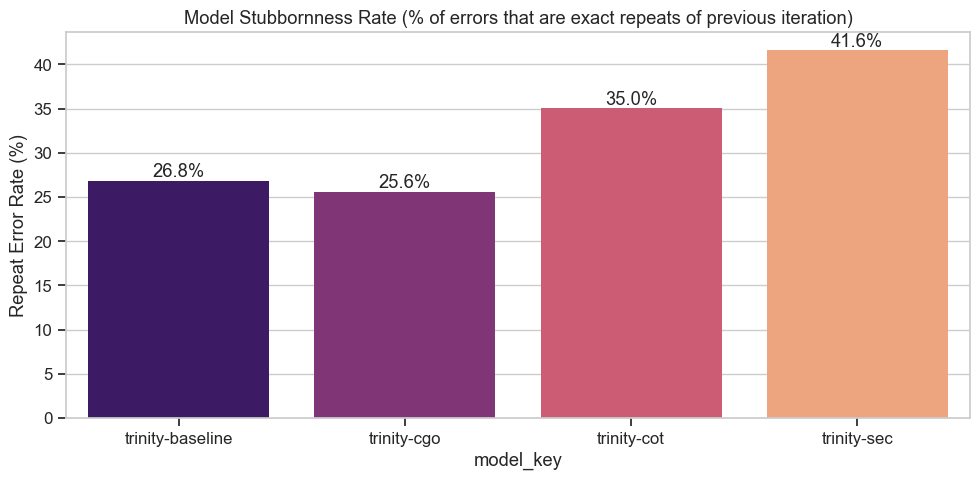

Example of a repeated error loop:


,model_key,row_number,iteration_number,resource_name,error_message
1,trinity-baseline,0,2,MySQSQueue | UseCustomQueueName | UseCustomVisibilityTimeout,'UseCustomQueueName' is not one of [] | 'UseCustomVisibilityTimeout' is not one of [] | Parameter UseCustomQueueName not used. | Parameter UseCustomVisibilityTimeout not used.
2,trinity-baseline,0,3,MySQSQueue | UseCustomQueueName | UseCustomVisibilityTimeout,'UseCustomQueueName' is not one of [] | 'UseCustomVisibilityTimeout' is not one of [] | Parameter UseCustomQueueName not used. | Parameter UseCustomVisibilityTimeout not used.
3,trinity-baseline,0,4,MySQSQueue | UseCustomQueueName | UseCustomVisibilityTimeout,'UseCustomQueueName' is not one of [] | 'UseCustomVisibilityTimeout' is not one of [] | Parameter UseCustomQueueName not used. | Parameter UseCustomVisibilityTimeout not used.
4,trinity-baseline,0,5,MySQSQueue | UseCustomQueueName | UseCustomVisibilityTimeout,'UseCustomQueueName' is not one of [] | 'UseCustomVisibilityTimeout' is not one of [] | Parameter UseCustomQueueName not used. | Parameter UseCustomVisibilityTimeout not used.
10,trinity-baseline,6,2,EC2Instance,'Fn::Sub' isn't needed because there are no variables


In [19]:
history_sorted = history_df.dropna(subset=['error_message', 'model_key', 'row_number']).copy()

history_sorted['row_number'] = history_sorted['row_number'].astype(int)
history_sorted['iteration_number'] = pd.to_numeric(history_sorted['iteration_number'], errors='coerce').fillna(0).astype(int)
history_sorted['resource_name'] = history_sorted['resource_name'].fillna('Unknown_Resource').astype(str)
history_sorted['error_message'] = history_sorted['error_message'].astype(str)

history_sorted = history_sorted.sort_values(by=['model_key', 'row_number', 'iteration_number'])

history_sorted['prev_error'] = history_sorted.groupby(
    ['model_key', 'row_number', 'resource_name'])['error_message'].shift(1)

ignore_list = ['N/A', 'Unknown', 'nan', 'None', '']
history_sorted['is_repeat'] = (
    (history_sorted['error_message'] == history_sorted['prev_error']) &
    (~history_sorted['error_message'].isin(ignore_list))
)

repeat_rates = history_sorted.groupby('model_key')['is_repeat'].mean() * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=repeat_rates.index, y=repeat_rates.values, palette='magma')
plt.title('Model Stubbornness Rate (% of errors that are exact repeats of previous iteration)')
plt.ylabel('Repeat Error Rate (%)')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('plots/model_stubbornness.png')
plt.show()

print("Example of a repeated error loop:")
repeats_df = history_sorted[history_sorted['is_repeat'] == True]
if not repeats_df.empty:
    pd.set_option('display.max_colwidth', None)
    display(repeats_df[['model_key', 'row_number', 'iteration_number', 'resource_name', 'error_message']].head())
else:
    print("No exact repeated errors found!")

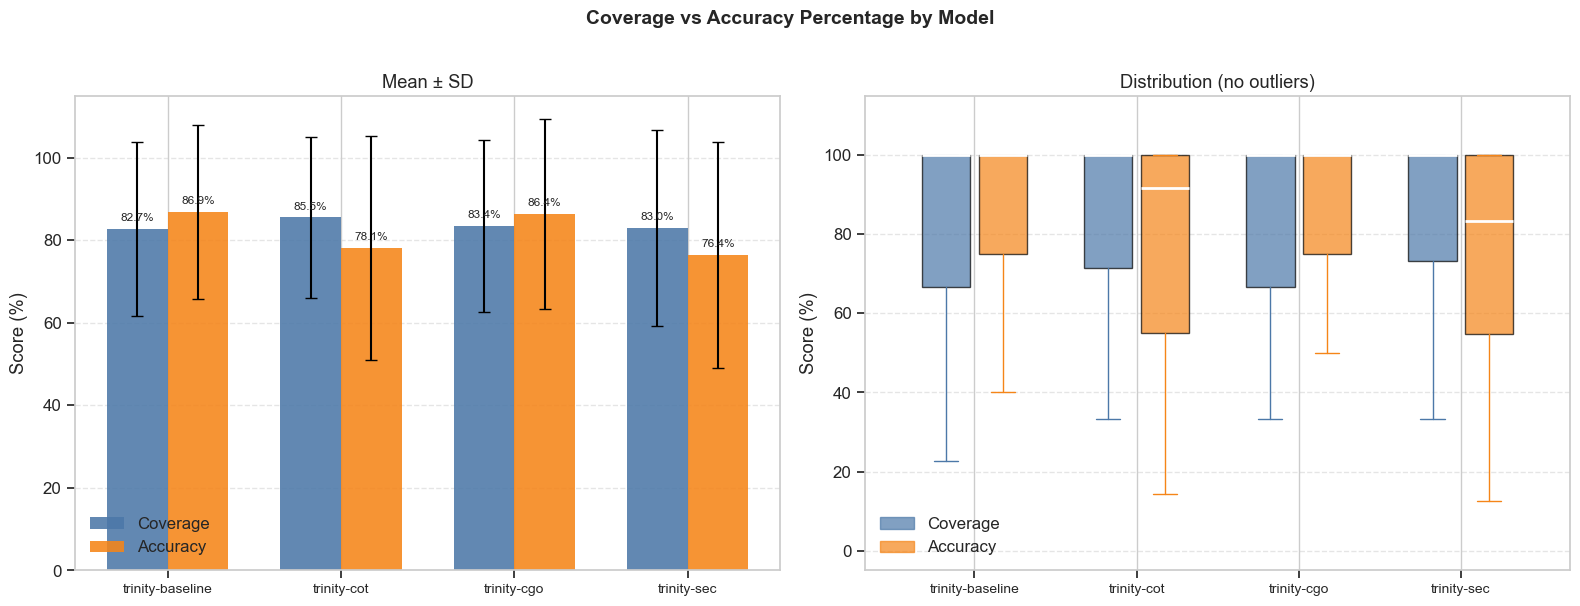

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# MODEL_ORDER = ['trinity-baseline', 'trinity-cot', 'trinity-scot', 'trinity-cgo', 'trinity-tdd']
MODEL_ORDER = ['trinity-baseline', 'trinity-cot', 'trinity-cgo', 'trinity-sec']
# MODEL_ORDER = ['claude-3-5', 'claude-3-7', 'deepseek-chat', 'deepseek-reasoner', 'gpt-4o', 'o3-mini']
DISPLAY     = ['Claude-3.5','Claude-3.7','GPT-4o','o3-mini','DS-Reasoner','DS-Chat']

agg = results_df.groupby('model_key').agg(
    cov_mean=('coverage_percentage','mean'),
    cov_std =('coverage_percentage','std'),
    acc_mean=('accuracy_percentage','mean'),
    acc_std =('accuracy_percentage','std'),
).reindex(MODEL_ORDER).reset_index()

x     = np.arange(len(MODEL_ORDER))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Coverage vs Accuracy Percentage by Model', fontsize=14, fontweight='bold', y=1.01)

# ── Left: grouped bar ─────────────────────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - width/2, agg['cov_mean'], width, yerr=agg['cov_std'],
               label='Coverage', color='#4C78A8', capsize=4, alpha=0.88)
bars2 = ax.bar(x + width/2, agg['acc_mean'], width, yerr=agg['acc_std'],
               label='Accuracy', color='#F58518', capsize=4, alpha=0.88)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=8.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Mean ± SD')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# ── Right: box plot ───────────────────────────────────────────────────────────
ax2 = axes[1]

cov_data = [results_df[results_df['model_key']==m]['coverage_percentage'].dropna().values for m in MODEL_ORDER]
acc_data = [results_df[results_df['model_key']==m]['accuracy_percentage'].dropna().values for m in MODEL_ORDER]

positions_cov = x - width/2
positions_acc = x + width/2

bp1 = ax2.boxplot(cov_data, positions=positions_cov, widths=width*0.85,
                  patch_artist=True, showfliers=False,
                  boxprops=dict(facecolor='#4C78A8', alpha=0.7),
                  medianprops=dict(color='white', linewidth=2),
                  whiskerprops=dict(color='#4C78A8'),
                  capprops=dict(color='#4C78A8'))

bp2 = ax2.boxplot(acc_data, positions=positions_acc, widths=width*0.85,
                  patch_artist=True, showfliers=False,
                  boxprops=dict(facecolor='#F58518', alpha=0.7),
                  medianprops=dict(color='white', linewidth=2),
                  whiskerprops=dict(color='#F58518'),
                  capprops=dict(color='#F58518'))

ax2.set_xticks(x)
ax2.set_xticklabels(MODEL_ORDER, fontsize=10)
ax2.set_ylim(-5, 115)
ax2.set_ylabel('Score (%)')
ax2.set_title('Distribution (no outliers)')
ax2.legend(handles=[
    mpatches.Patch(color='#4C78A8', alpha=0.7, label='Coverage'),
    mpatches.Patch(color='#F58518', alpha=0.7, label='Accuracy'),
])
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plots/coverage_accuracy.png')
plt.show()


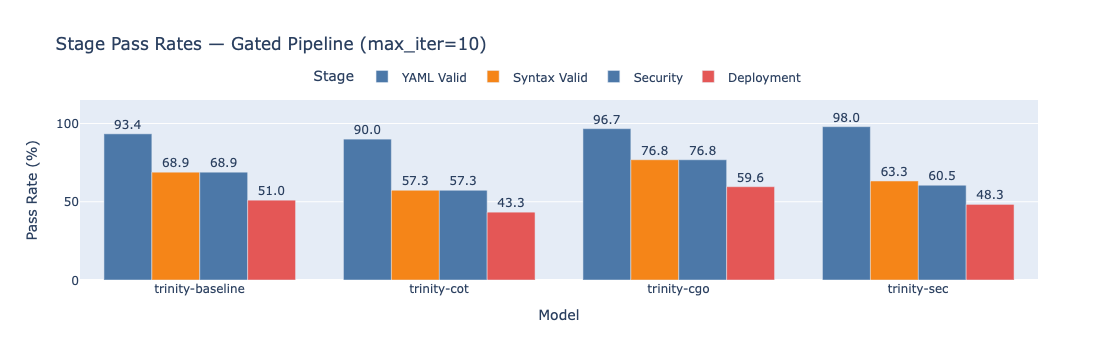


Stage Pass Rates at max_iter=10:
                  Deployment  Security  Syntax Valid  YAML Valid
model_key                                                       
trinity-baseline        51.0      68.9          68.9        93.4
trinity-cgo             59.6      76.8          76.8        96.7
trinity-cot             43.3      57.3          57.3        90.0
trinity-sec             48.3      60.5          63.3        98.0


In [39]:
# ── Stage Pass Rate by Model — Sequential Gated Pipeline ─────────────────────
# Pipeline: yaml_validation → syntax_validation → deployment
#
# YAML pass    : task reached syntax stage at least once within max_iter
# Syntax pass  : task reached deployment stage at least once within max_iter
# Deploy pass  : task succeeded within max_iter
#
# A task that never progresses past a stage FAILS that stage and all downstream.
import plotly.express as px

MAX_ITER = 10   # <-- configure iteration budget here

STAGES       = ['yaml_validation', 'syntax_validation', 'security', 'deployment']
STAGE_LABELS = {'yaml_validation':'YAML Valid','syntax_validation':'Syntax Valid',
                'deployment':'Deployment', 'security': 'Security'}
COLORS       = {'yaml_validation':'#4C78A8','syntax_validation':'#F58518',
                'deployment':'#E45756', 'security':'#4C78A8'}

errors_df = history_df.copy()

# Pre-process: ensure numeric types
for _df in [results_df, errors_df]:
    _df['row_number'] = pd.to_numeric(_df['row_number'], errors='coerce')
errors_df['iteration_number'] = pd.to_numeric(errors_df['iteration_number'], errors='coerce')
results_df.dropna(subset=['row_number'], inplace=True)
errors_df.dropna(subset=['row_number'],  inplace=True)
results_df['row_number'] = results_df['row_number'].astype(int)
errors_df['row_number']  = errors_df['row_number'].astype(int)

def compute_stage_pass_rates(results_df, errors_df, max_iter=10):
    records = []
    for model in results_df['model_key'].unique():
        r = results_df[results_df['model_key'] == model]
        e = errors_df[(errors_df['model_key'] == model) &
                      (errors_df['iteration_number'] <= max_iter)]
        total = len(r);  all_rows = set(r['row_number'])
        if total == 0: continue

        reached_syntax = set(e[e['error_stage'] == 'syntax_validation']['row_number'])
        reached_security = set(e[e['error_stage'] == 'security_validation']['row_number'])
        reached_deploy = set(e[e['error_stage'] == 'deployment']['row_number'])
        succeeded      = set(r[(r['success'] == True) &
                               (r['total_iterations'] <= max_iter)]['row_number'])

        # YAML pass  = ever reached syntax OR deployment stage OR succeeded
        yaml_pass   = (reached_syntax | reached_security | reached_deploy | succeeded) & all_rows
        # Syntax pass = ever reached deployment stage OR succeeded
        syntax_pass = (reached_security | reached_deploy | succeeded) & all_rows
        security_pass = (reached_deploy | succeeded) & all_rows
        # Deploy pass = succeeded
        deploy_pass = succeeded & all_rows

        for stage, passed in [('yaml_validation', yaml_pass),
                               ('syntax_validation', syntax_pass),
                               ('security', security_pass),
                               ('deployment', deploy_pass)]:
            records.append({'model_key': model, 'stage': stage,
                            'pass_rate': len(passed) / total * 100,
                            'passed': len(passed), 'total': total,
                            'max_iter': max_iter})
    return pd.DataFrame(records)

df_stage = compute_stage_pass_rates(results_df, errors_df, max_iter=MAX_ITER)
df_stage['stage_label'] = df_stage['stage'].map(STAGE_LABELS)

fig = px.bar(
    df_stage, x='model_key', y='pass_rate', color='stage_label',
    barmode='group',
    category_orders={'stage_label': [STAGE_LABELS[s] for s in STAGES]},
    color_discrete_map={STAGE_LABELS[s]: COLORS[s] for s in STAGES},
    text_auto='.1f',
    labels={'pass_rate':'Pass Rate (%)','model_key':'Model','stage_label':'Stage'},
    title=f'Stage Pass Rates — Gated Pipeline (max_iter={MAX_ITER})',
)
fig.update_layout(yaxis_range=[0,115],
    legend=dict(orientation='h', yanchor='bottom', y=1.05, xanchor='center', x=0.5))
fig.update_traces(cliponaxis=False, textposition='outside')
fig.write_image('plots/stage_pass_rates.png')
fig.show()

# Print summary table
pivot = df_stage.pivot(index='model_key', columns='stage', values='pass_rate')
pivot.columns = [STAGE_LABELS[c] for c in pivot.columns]
print(f"\nStage Pass Rates at max_iter={MAX_ITER}:")
print(pivot.round(1).to_string())


## 4. Resource Vulnerability & Keyword Analysis
Which AWS resources cause the deployment to crash? We extract the text from the API rejection messages to see *why* deployment fails (e.g., hallucinated Engine versions, missing Docker dependencies).

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_92987/585862752.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_resources.values, y=top_resources.index, palette='viridis')


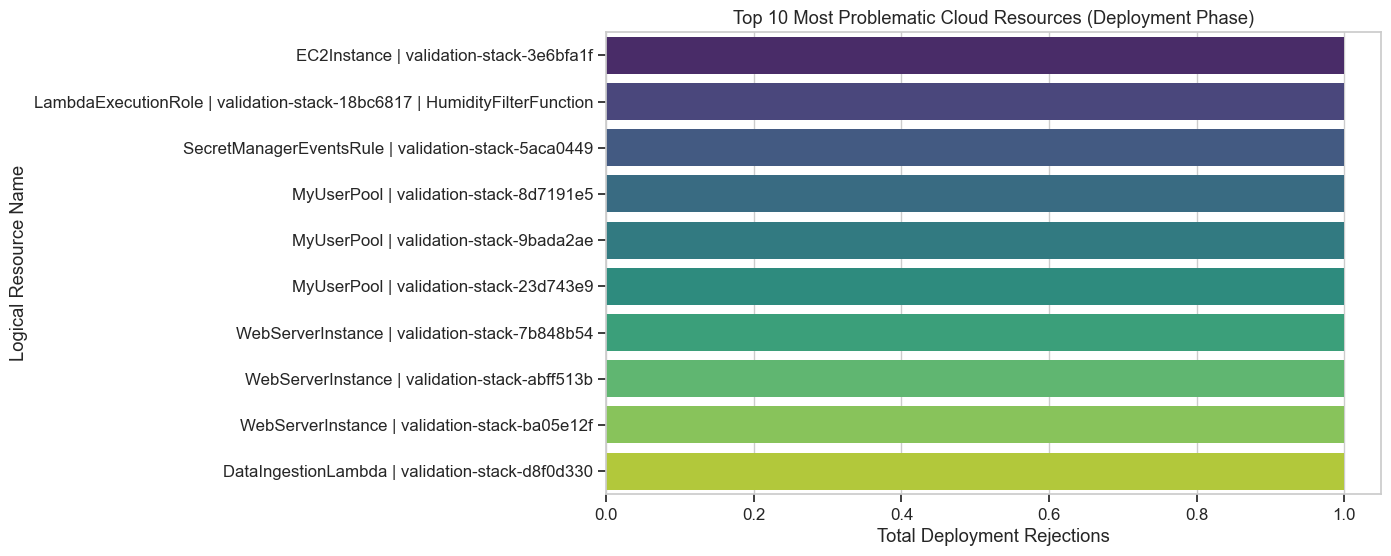

Evidence of Hallucinations / Logic Errors in Deployment:


,model_key,resource_name,error_message
16,trinity-baseline,EC2Instance | validation-stack-3e6bfa1f,Resource provider operation failed: An error occurred (InvalidAMIID.NotFound) when calling the RunInstances operation: The image id 'ami-0c55b159cbfafe1f0' does not exist
17,trinity-baseline,EC2Instance | validation-stack-28b8eb30,Resource provider operation failed: An error occurred (InvalidAMIID.NotFound) when calling the RunInstances operation: The image id 'ami-0c55b159cbfafe1f0' does not exist
18,trinity-baseline,EC2Instance | validation-stack-90cbac36,Resource provider operation failed: An error occurred (InvalidAMIID.NotFound) when calling the RunInstances operation: The image id 'ami-0c55b159cbfafe1f0' does not exist
21,trinity-baseline,MyEFSMountTarget | validation-stack-13dc2f45,Resource provider operation failed: An error occurred (SubnetNotFound) when calling the CreateMountTarget operation: The subnet ID 'subnet-12345678' does not exist
35,trinity-baseline,EC2Instance,Resource provider operation failed: An error occurred (InvalidAMIID.NotFound) when calling the RunInstances operation: The image id 'ami-0c55b159cbfafe1f0' does not exist


In [127]:
deployment_errors = history_df[history_df['error_stage'] == 'deployment']
top_resources = deployment_errors['resource_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_resources.values, y=top_resources.index, palette='viridis')
plt.title('Top 10 Most Problematic Cloud Resources (Deployment Phase)')
plt.xlabel('Total Deployment Rejections')
plt.ylabel('Logical Resource Name')
plt.savefig('plots/problematic_resources.png')
plt.show()

print("Evidence of Hallucinations / Logic Errors in Deployment:")
hallucinations = deployment_errors[deployment_errors['error_message'].str.contains(
    'Cannot find version|does not exist|InvalidRequest', na=False, case=False)]
pd.set_option('display.max_colwidth', None)
display(hallucinations[['model_key', 'resource_name', 'error_message']].drop_duplicates().head(5))

## 5. Error Taxonomy Deep Dive
Grounding the data in the NL2IaC Error Taxonomy (Nekrasov et al., 2025), errors split across two dimensions:
- **Dimension 1 (Validation Stage):** `syntax` → `schema` → `runtime` → `intent`
- **Dimension 2 (LLM Failure Pattern):** Factual Incorrectness (FI) | Incompleteness (IC) | Contextual Reasoning Failure (CRF) | Structural Deficit (SD)

Key finding from the taxonomy: *"Schema-related issues overwhelmingly dominate, constituting 94.5% of all technical validation failures. Factual Incorrectness emerges as the leading cause (65%), followed by Incompleteness (26.5%)."* (Nekrasov et al., 2025)

This cell classifies each `error_message` in our `history_df` into those four failure patterns using keyword heuristics derived from the paper, then visualises the distribution across models.

Reclassified by stage context: 189 / 2,156 rows (8.8%)

Stage × Category breakdown:


failure_pattern,Contextual Reasoning Failure,Factual Incorrectness,Incompleteness,Other / Unclassified,Structural Deficit
error_stage,,,,,
deployment,119,217,24,28,14
syntax_validation,54,458,269,715,0
yaml_validation,0,0,0,0,258


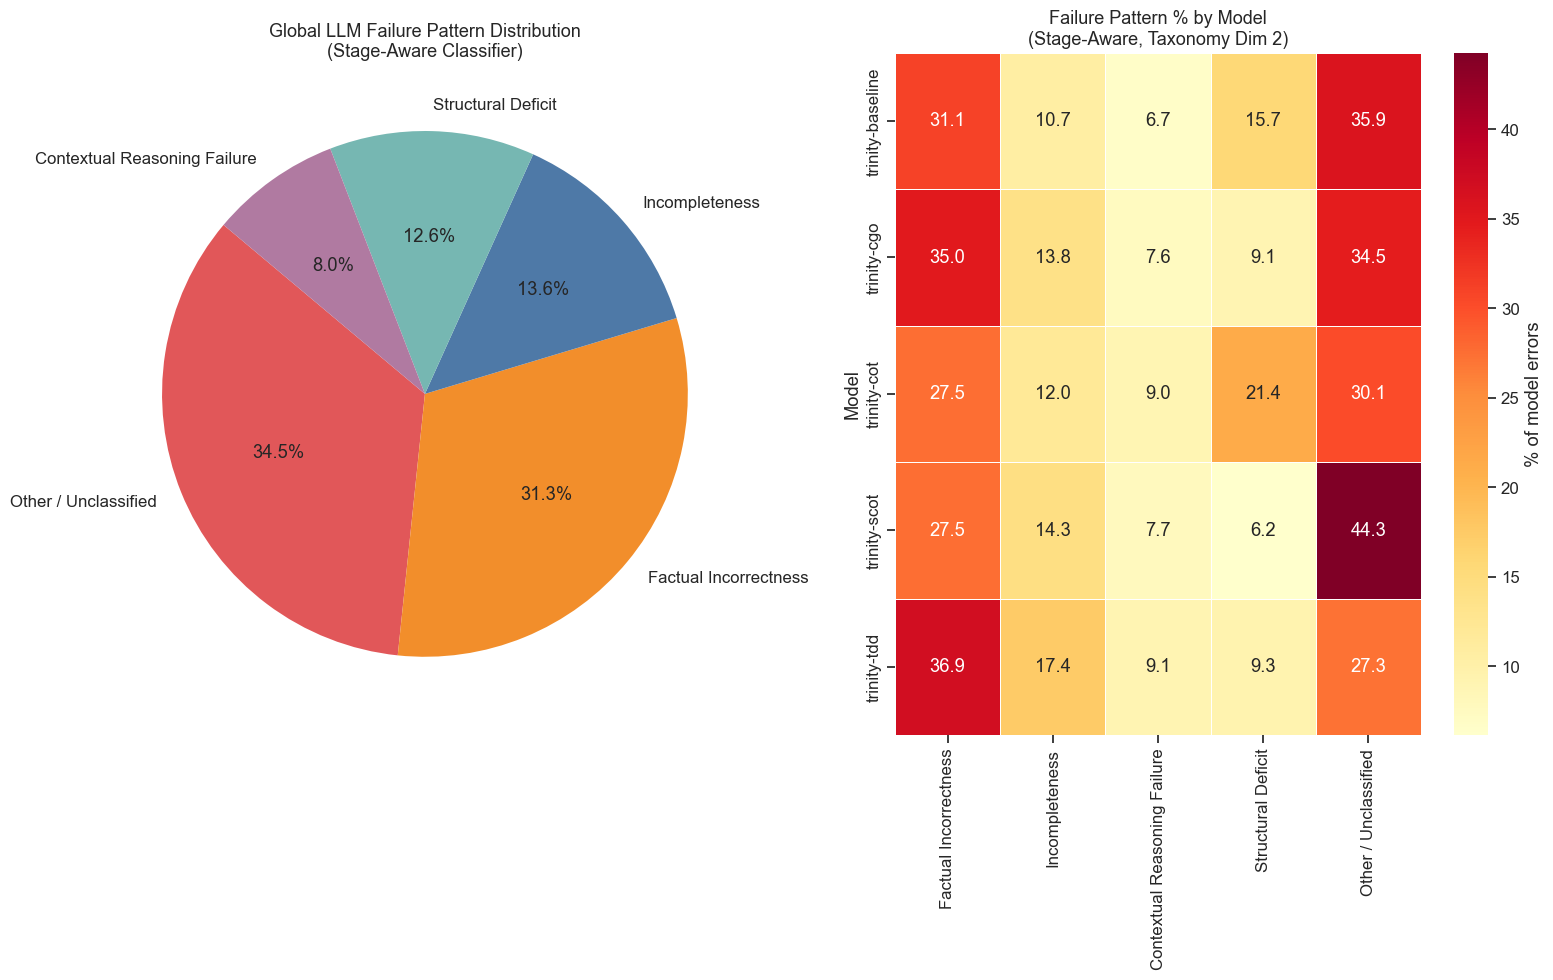


Absolute counts per model × pattern:


failure_pattern,Factual Incorrectness,Incompleteness,Contextual Reasoning Failure,Structural Deficit,Other / Unclassified
model_key,,,,,
trinity-baseline,131,45,28,66,151
trinity-cgo,134,53,29,35,132
trinity-cot,135,59,44,105,148
trinity-scot,125,65,35,28,201
trinity-tdd,150,71,37,38,111


In [141]:
# ── Stage-Aware Heuristic Classifier: Nekrasov et al. (2025) Taxonomy ────────
# Combines error_stage (hard gate) + error_message (keyword matching)
# Priority: stage context → category-specific keywords → fallback waterfall
import re

# ── Keyword sets (unchanged from your original) ───────────────────────────────
FI_KEYWORDS = (
    r'does not exist|not found|invalid|unrecognized|unsupported argument|unsupported block'
    r'|no such|hallucin|deprecated|InvalidRequest|not supported|unknown property'
    r'|unknown attribute|unknown resource type|unknown type'
    r'|is not one of|is not a valid|not a valid value|not valid for type'
    r'|not a valid enum|not in enum|not an allowed value|allowed values are'
    r'|cannot find version|engine version|invalid engine'
    r'|ami.*not found|image.*not found|no longer available'
    r'|resource type.*not found|type.*does not exist'
    r'|getatt.*not supported|getatt.*invalid|invalid getatt'
    r'|property.*not valid|property.*not allowed|property.*unknown'
    r'|incorrect type|value must be|must be one of|must be between'
    r'|invalid parameter|invalid value|bad value|value out of range'
    r'|cannot be empty|cannot be null|cannot be blank'
    r'|not recognized|not a recognized|no handler found'
    r'|wrong number|too many|too few|exceeds maximum|below minimum'
)

IC_KEYWORDS = (
    r'missing required|required argument|required property|must have|must be provided'
    r'|expected.*not found|attribute.*required|parameter.*required|must have values'
    r'|missing property|missing attribute|missing field|missing parameter'
    r'|must be specified|must specify|must include|must contain|must define'
    r'|no.*provided|not provided|not specified|not defined|not declared'
    r'|parameters.*must have values|parameters.*no value'
    r'|subnet.*required|vpc.*required|security group.*required'
    r'|key.*required|certificate.*required|role.*required'
    r'|cannot be none|value is required|field is required'
    r'|no default value|no value for'
    r'|at least one|one of.*must be|exactly one.*required'
    r'|resource.*incomplete|incomplete.*definition|incomplete.*configuration'
)

CRF_KEYWORDS = (
    r'conflict|circular|dependency|duplicate|already exists|wrong type|cannot reference'
    r'|not allowed.*here|incompatible|ValidationError'
    r'|depends on|dependson|cyclic|cycle detected|circular dependency'
    r'|reference.*not found|ref.*not found|cannot find ref|no resource.*named'
    r'|cross.?stack|export.*not found|import.*not found'
    r'|subnet.*not in vpc|not in the same vpc|vpc.*mismatch'
    r'|security group.*not.*vpc|sg.*not.*vpc'
    r'|iam.*not.*role|cannot assume|trust.*policy|no permission'
    r'|execution role|lambda.*role|task.*role|service.*role'
    r'|integration.*not defined|no integration|method.*no integration'
    r'|target group.*not found|listener.*not found|load balancer.*not found'
    r'|db subnet group.*not in vpc|subnet group.*mismatch'
    r'|already.*in use|already.*attached|already.*associated'
    r'|cannot delete.*in use|resource.*in use|still.*referenced'
    r'|rollback|stack.*failed|update.*failed|replace.*failed'
    r'|resource handler returned|resource.*stabilize|failed to stabilize'
)

SD_KEYWORDS = (
    r'yaml syntax|indentation|parsing error|format error|unexpected char|tabs.*spaces'
    r'|whitespace|bracket|colon expected|json decode'
    r'|yaml.*error|invalid yaml|yaml.*invalid|malformed yaml'
    r'|json.*error|invalid json|json.*invalid|malformed json'
    r'|mapping values|block sequence|block mapping|scalar|anchor'
    r'|unexpected end|premature end|unexpected token|unexpected symbol'
    r'|could not find expected|did not find expected'
    r'|template format error|template.*not valid|not valid.*template'
    r'|awstemplateformatversion.*missing|missing.*awstemplateformatversion'
    r'|resources.*missing|no resources|resources.*empty'
    r'|duplicate key|duplicate.*mapping|duplicate.*field'
    r'|encoding error|unicode|utf.?8|invalid character|control character'
    r'|null byte|binary.*not allowed|non-printable'
    r'|tab character|mixed indentation|inconsistent indentation'
    r'|line \d+.*column|column \d+.*line'
)

# ── Stage → category priority map ─────────────────────────────────────────────
# Each stage maps to an ORDERED list of (pattern, category) tuples.
# The first match wins; if none match, falls through to 'Other / Unclassified'.
STAGE_PRIORITY = {
    # yaml_validation: structural errors by definition — no keyword needed
    'yaml_validation': [
        (None, 'Structural Deficit'),        # hard-assign; None = unconditional
    ],
    # syntax_validation (cfn-lint): mostly FI, IC is secondary, SD rare fallback
    'syntax_validation': [
        (SD_KEYWORDS,  'Structural Deficit'),          # cfn-lint template structure errors
        (IC_KEYWORDS,  'Incompleteness'),
        (FI_KEYWORDS,  'Factual Incorrectness'),
        (CRF_KEYWORDS, 'Contextual Reasoning Failure'),
    ],
    # deployment (AWS API): CRF dominates, IC second (missing params), FI third
    'deployment': [
        (CRF_KEYWORDS, 'Contextual Reasoning Failure'),
        (IC_KEYWORDS,  'Incompleteness'),
        (FI_KEYWORDS,  'Factual Incorrectness'),
        (SD_KEYWORDS,  'Structural Deficit'),           # e.g. TemplateFormatError
    ],
}

# Fallback waterfall for unknown/missing stage (original order)
FALLBACK_PRIORITY = [
    (SD_KEYWORDS,  'Structural Deficit'),
    (IC_KEYWORDS,  'Incompleteness'),
    (CRF_KEYWORDS, 'Contextual Reasoning Failure'),
    (FI_KEYWORDS,  'Factual Incorrectness'),
]


def classify_failure_pattern(row) -> str:
    """
    Stage-aware classifier.
    Uses error_stage as a hard gate to select the priority ordering,
    then applies keyword matching within that gate.
    """
    msg   = str(row.get('error_message', '')).lower()
    stage = str(row.get('error_stage',   '')).lower().strip()

    priority_list = STAGE_PRIORITY.get(stage, FALLBACK_PRIORITY)

    for pattern, category in priority_list:
        if pattern is None:                        # unconditional hard-assign
            return category
        if re.search(pattern, msg, re.I):
            return category

    return 'Other / Unclassified'


# ── Apply (uses both columns) ─────────────────────────────────────────────────
history_df['failure_pattern'] = history_df.apply(classify_failure_pattern, axis=1)

# ── Optional: inspect reclassification delta vs message-only baseline ─────────
msg_only = history_df['error_message'].apply(
    lambda m: next(
        (cat for pat, cat in FALLBACK_PRIORITY if re.search(pat, str(m), re.I)),
        'Other / Unclassified'
    )
)
changed = (msg_only != history_df['failure_pattern']).sum()
print(f"Reclassified by stage context: {changed:,} / {len(history_df):,} rows "
      f"({changed/len(history_df)*100:.1f}%)")
print("\nStage × Category breakdown:")
display(
    history_df.groupby(['error_stage','failure_pattern'])
    .size().unstack(fill_value=0)
)

# ── A: Global distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

global_dist = history_df['failure_pattern'].value_counts()
palette_fp  = ['#E15759','#F28E2B','#4E79A7','#76B7B2','#B07AA1']
axes[0].pie(global_dist.values, labels=global_dist.index, autopct='%1.1f%%',
            colors=palette_fp[:len(global_dist)], startangle=140)
axes[0].set_title('Global LLM Failure Pattern Distribution\n(Stage-Aware Classifier)', fontsize=13)

# ── B: Per-model heatmap ──────────────────────────────────────────────────────
pattern_order = ['Factual Incorrectness','Incompleteness',
                 'Contextual Reasoning Failure','Structural Deficit',
                 'Other / Unclassified']
model_pattern = (
    history_df.groupby(['model_key','failure_pattern'])
    .size().unstack(fill_value=0)
    .reindex(columns=[p for p in pattern_order if p in history_df['failure_pattern'].unique()],
             fill_value=0)
)
model_pattern_pct = model_pattern.div(model_pattern.sum(axis=1), axis=0) * 100

sns.heatmap(model_pattern_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% of model errors'})
axes[1].set_title('Failure Pattern % by Model\n(Stage-Aware, Taxonomy Dim 2)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Model')
plt.tight_layout()
plt.show()

print("\nAbsolute counts per model × pattern:")
display(model_pattern)


## 6. Self-Healing Efficiency: Iterations-to-Resolution
Not all error types are equally recoverable. This section measures how many feedback iterations each model needs to *clear* a specific failure pattern — a proxy for how well the model integrates error feedback for different cognitive failure modes.

**Hypothesis:** Structural Deficits (whitespace, YAML syntax) should resolve quickly (1–2 iterations) because they are mechanically unambiguous. Factual Incorrectness (hallucinated arguments, deprecated engine versions) and Contextual Reasoning Failures (circular dependencies, wrong resource types) should require more iterations — or remain stuck — reflecting the Correctness-Congruence Gap described by Nekrasov et al. (2025).

IaCGen paper (Zhang et al., 2025): *"Without accessing the entire conversation history, LLMs frequently reintroduce previously corrected errors when addressing new issues — the Error Recurrence phenomenon."*

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_92987/393610597.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


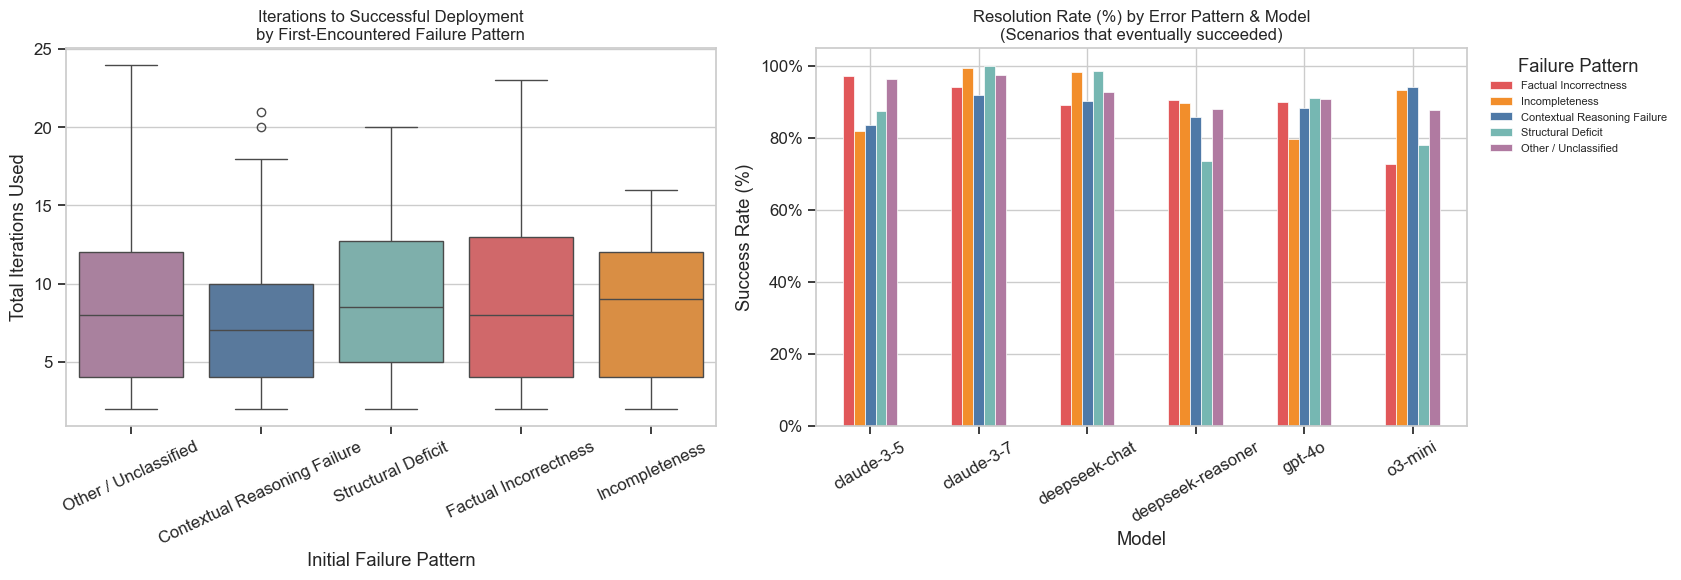


Mean iterations per (model, first failure pattern) for successful scenarios:


mean  median  count
model_key         first_failure_pattern                             
claude-3-5        Contextual Reasoning Failure   5.53     5.0     32
                  Factual Incorrectness          7.18     7.0     17
                  Other / Unclassified           6.24     5.5     46
                  Structural Deficit             6.00     5.0      8
claude-3-7        Contextual Reasoning Failure   5.38     4.0     34
                  Factual Incorrectness          6.76     4.0     21
                  Incompleteness                 7.60     8.0      5
                  Other / Unclassified           6.26     6.0     46
                  Structural Deficit             7.33     5.0      3
deepseek-chat     Contextual Reasoning Failure   8.75     8.5     32
                  Factual Incorrectness          9.53     9.0     17
                  Incompleteness                 7.60     9.0      5
                  Other / Unclassified          10.70    12.0     47
                  Structural Deficit            11.50    11.5      4
deepseek-reasoner Contextual Reasoning Failure   7.67     7.5     30
                  Factual Incorrectness         10.85    12.0     13
                  Incompleteness                 8.25     8.5      4
                  Other / Unclassified           7.43     5.0     44
                  Structural Deficit             7.64     9.0     11
gpt-4o            Contextual Reasoning Failure   9.53     9.5     30
                  Factual Incorrectness          9.48     8.0     21
                  Incompleteness                 9.80    13.0      5
                  Other / Unclassified          10.24    11.0     37
                  Structural Deficit             9.47     8.0     15
o3-mini           Contextual Reasoning Failure   9.48     8.0     23
                  Factual Incorrectness          8.87     8.0     23
                  Incompleteness                10.00    10.0      2
                  Other / Unclassified          10.37     9.0     30
                  Structural Deficit             9.67     9.0     33

In [107]:
# Merge history with results to know final outcome per (model, scenario)
merged = history_df.merge(
    results_df[['model_key','row_number','success','total_iterations']],
    left_on=['model_key','row_number'],
    right_on=['model_key','row_number'],
    how='left'
)

# ── A: Boxplot – iterations used by successful scenarios, split by first failure pattern ──
successful = merged[merged['success'] == True].copy()
# Tag each scenario with the first failure pattern encountered
first_pattern = (
    successful.sort_values('iteration_number')
    .groupby(['model_key','row_number'])['failure_pattern']
    .first().reset_index()
    .rename(columns={'failure_pattern': 'first_failure_pattern'})
)
success_itr = successful.merge(first_pattern, on=['model_key','row_number'], how='left')

itr_by_pattern = (
    success_itr.drop_duplicates(subset=['model_key','row_number'])
    [['model_key','first_failure_pattern','total_iterations']]
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

pattern_palette = {
    'Factual Incorrectness': '#E15759',
    'Incompleteness': '#F28E2B',
    'Contextual Reasoning Failure': '#4E79A7',
    'Structural Deficit': '#76B7B2',
    'Other / Unclassified': '#B07AA1'
}
sns.boxplot(
    data=itr_by_pattern, x='first_failure_pattern', y='total_iterations',
    palette=pattern_palette, ax=axes[0]
)
axes[0].set_title('Iterations to Successful Deployment\nby First-Encountered Failure Pattern', fontsize=12)
axes[0].set_xlabel('Initial Failure Pattern')
axes[0].set_ylabel('Total Iterations Used')
axes[0].tick_params(axis='x', rotation=25)

# ── B: Stacked bar – resolution rate per pattern per model ──
resolution = merged.groupby(['model_key','failure_pattern'])['success'].mean().unstack(fill_value=0) * 100
resolution[[c for c in pattern_order if c in resolution.columns]].plot(
    kind='bar', stacked=False, ax=axes[1],
    color=[pattern_palette.get(p,'grey') for p in pattern_order if p in resolution.columns],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Resolution Rate (%) by Error Pattern & Model\n(Scenarios that eventually succeeded)', fontsize=12)
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Failure Pattern', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

print("\nMean iterations per (model, first failure pattern) for successful scenarios:")
display(
    itr_by_pattern.groupby(['model_key','first_failure_pattern'])['total_iterations']
    .agg(['mean','median','count']).round(2)
)

## 7. Stubbornness Decomposed by Failure Pattern
The raw stubbornness rate (Section 3) treats all repeat errors equally. This cell breaks the repeat-error rate down *per failure pattern*, revealing which cognitive failure mode is most resistant to feedback. The critical insight from IaCGen (Zhang et al., 2025):

> *"o3-mini consistently inserts extraneous whitespace adjacent to brackets. This error is particularly resistant to correction, often requiring explicit prompt rather than general instructions to resolve."*

Hypothesis: **Structural Deficits** have a high repeat rate despite being mechanically fixable — they are brittle formatting issues the model re-introduces when patching other errors. **Factual Incorrectness** (hallucinated schema elements) should also have a high repeat rate because the model's parametric memory cannot be corrected via prompt feedback alone.

In [109]:
# Attach failure pattern to history_sorted (which already has is_repeat)
history_sorted['failure_pattern'] = history_sorted['error_message'].apply(classify_failure_pattern)

# Repeat rate per (model, failure_pattern)
stub_pattern = (
    history_sorted
    .groupby(['model_key','failure_pattern'])['is_repeat']
    .mean().mul(100).reset_index()
    .rename(columns={'is_repeat': 'repeat_rate_pct'})
)

pivot = stub_pattern.pivot(index='model_key', columns='failure_pattern', values='repeat_rate_pct').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.heatmap(
    pivot[[c for c in pattern_order if c in pivot.columns]],
    annot=True, fmt='.1f', cmap='Reds', linewidths=0.5,
    ax=axes[0], cbar_kws={'label': 'Repeat Error Rate (%)'}
)
axes[0].set_title('Model Stubbornness Heatmap\n(Repeat Rate % by Failure Pattern)', fontsize=12)
axes[0].set_xlabel('Failure Pattern')
axes[0].set_ylabel('Model')
axes[0].tick_params(axis='x', rotation=30)

# Grouped bar for easy cross-model comparison
stub_pattern_clean = stub_pattern[stub_pattern['failure_pattern'].isin(pattern_order[:-1])]
sns.barplot(
    data=stub_pattern_clean, x='failure_pattern', y='repeat_rate_pct',
    hue='model_key', palette='tab10', ax=axes[1]
)
axes[1].set_title('Stubbornness Rate per Failure Pattern\n(Grouped by Model)', fontsize=12)
axes[1].set_ylabel('Repeat Error Rate (%)')
axes[1].set_xlabel('Failure Pattern')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

AttributeError: 'str' object has no attribute 'get'

## 8. The Correctness-Congruence Gap Visualised
Nekrasov et al. (2025) coined the *Correctness-Congruence Gap*: LLMs can be coached to generate technically valid IaC (schema-correct, deployable) but consistently fail to satisfy the user's higher-level architectural intent. Their best Graph RAG method achieved **84.2% technical validation** but only **72–76% intent validation** — and this plateau persisted across all methods.

Zhang et al. (DPIaC-Eval, 2025) replicate this: Claude-3.5 reaches **95.5% deployability** (passItr15) yet only **25.5% of templates fully satisfy user intent** (resource + attribute coverage).

This cell computes the same gap from our dataset: the delta between *deployment success* and *intent alignment* (if `intent_success` column exists), or proxies intent via template complexity metrics.

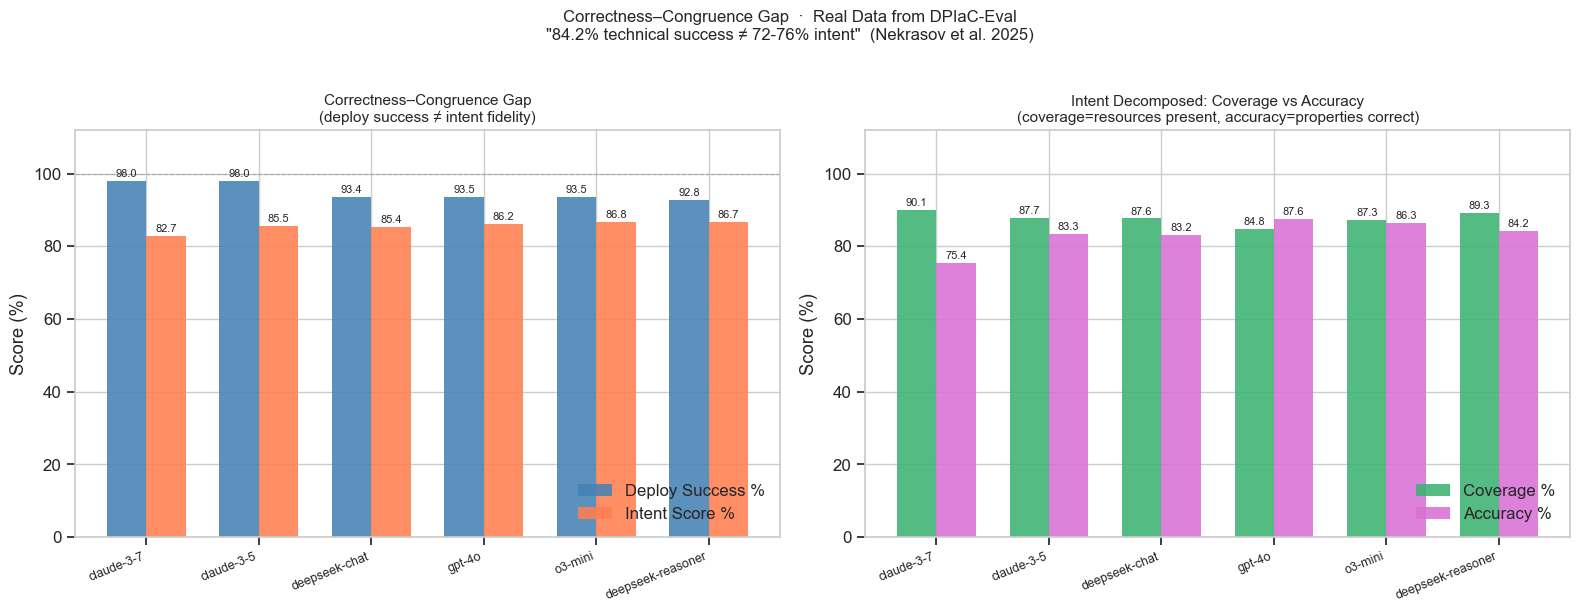


── Congruence Gap per model ──
        model_key  deploy_rate  avg_coverage  avg_accuracy  avg_intent  congruence_gap
       claude-3-7    98.039216     90.076601     75.358266   82.717433       15.321782
       claude-3-5    98.039216     87.690449     83.254412   85.472431       12.566785
    deepseek-chat    93.421053     87.638662     83.206042   85.422352        7.998700
           gpt-4o    93.464052     84.754496     87.592858   86.173677        7.290375
          o3-mini    93.464052     87.269844     86.303113   86.786479        6.677573
deepseek-reasoner    92.763158     89.255224     84.171827   86.713526        6.049632


In [99]:
# =============================================================================
# SECTION 6 – Correctness–Congruence Gap  (Nekrasov et al. 2025)
# coverage_percentage : fraction of ground-truth resources the model generated
# accuracy_percentage : fraction of properties correctly configured
# intent_score        : (coverage + accuracy) / 2
# congruence_gap      : deploy_rate - intent_score  ← the key metric
# =============================================================================

results_df['intent_score'] = (
    results_df['coverage_percentage'] + results_df['accuracy_percentage']
) / 2
results_df['deploy_success'] = results_df['success'].astype(bool)

model_intent = (
    results_df.groupby('model_key')
    .agg(
        deploy_rate  = ('deploy_success',       lambda x: x.mean() * 100),
        avg_coverage = ('coverage_percentage',  'mean'),
        avg_accuracy = ('accuracy_percentage',  'mean'),
        avg_intent   = ('intent_score',         'mean'),
        n_tasks      = ('row_number',           'count'),
    )
    .reset_index()
)
model_intent['congruence_gap'] = model_intent['deploy_rate'] - model_intent['avg_intent']
model_intent = model_intent.sort_values('congruence_gap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
w = 0.35

# --- LEFT: Deploy Rate vs Intent Score ---
ax = axes[0]
x = np.arange(len(model_intent))
b1 = ax.bar(x - w/2, model_intent['deploy_rate'], width=w,
            label='Deploy Success %', color='steelblue', alpha=0.88)
b2 = ax.bar(x + w/2, model_intent['avg_intent'],  width=w,
            label='Intent Score %',   color='coral',     alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(model_intent['model_key'], rotation=22, ha='right', fontsize=9)
ax.set_ylim(0, 112)
ax.set_ylabel('Score (%)')
ax.set_title('Correctness–Congruence Gap\n(deploy success ≠ intent fidelity)', fontsize=11)
ax.legend(loc='lower right')
ax.axhline(100, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
for b in list(b1) + list(b2):
    ax.annotate(f'{b.get_height():.1f}',
                xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

# --- RIGHT: Coverage vs Accuracy decomposition ---
ax2 = axes[1]
b3 = ax2.bar(x - w/2, model_intent['avg_coverage'], width=w,
             label='Coverage %',  color='mediumseagreen', alpha=0.88)
b4 = ax2.bar(x + w/2, model_intent['avg_accuracy'], width=w,
             label='Accuracy %',  color='orchid',          alpha=0.88)
ax2.set_xticks(x)
ax2.set_xticklabels(model_intent['model_key'], rotation=22, ha='right', fontsize=9)
ax2.set_ylim(0, 112)
ax2.set_ylabel('Score (%)')
ax2.set_title('Intent Decomposed: Coverage vs Accuracy\n(coverage=resources present, accuracy=properties correct)',
              fontsize=11)
ax2.legend(loc='lower right')
for b in list(b3) + list(b4):
    ax2.annotate(f'{b.get_height():.1f}',
                 xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

fig.suptitle(
    'Correctness–Congruence Gap  ·  Real Data from DPIaC-Eval\n'
    '"84.2% technical success ≠ 72-76% intent"  (Nekrasov et al. 2025)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print("\n── Congruence Gap per model ──")
print(model_intent[['model_key','deploy_rate','avg_coverage',
                     'avg_accuracy','avg_intent','congruence_gap']].to_string(index=False))


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_92987/3902316778.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tax_pct.index, rotation=22, ha='right', fontsize=9)


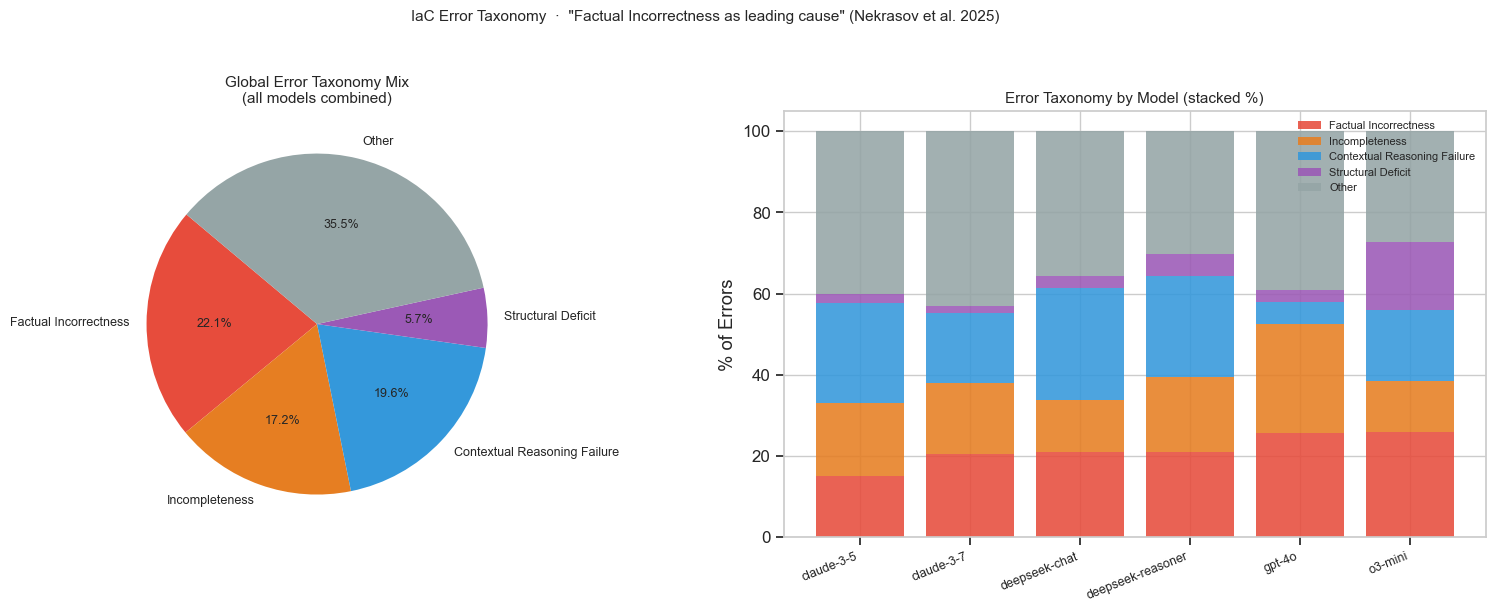


── Global taxonomy counts ──
taxonomy
Other                           3529
Factual Incorrectness           2198
Contextual Reasoning Failure    1947
Incompleteness                  1713
Structural Deficit               564


In [101]:
# =============================================================================
# SECTION 7 – Error Taxonomy Deep Dive
# Classifies every error_message into 4 failure patterns from Nekrasov et al.
# =============================================================================

import re

def classify_error(msg: str) -> str:
    """
    Classify a CloudFormation/cfn-lint error message into one of four taxonomy
    categories. Priority order: SD → IC → FI → CRF → Uncategorised.

    SD must be checked first because YAML parse errors contain phrases like
    'not allowed here' or 'invalid' that would otherwise false-match FI/CRF.
    IC before FI because 'must have values' is a stronger incompleteness signal
    than the generic 'invalid' catch-all in FI.
    """
    m = str(msg).lower()

    # ── 1. Structural Deficit ─────────────────────────────────────────────
    # YAML/JSON parse failures, template skeleton violations — always wins
    if re.search(
        r'yaml syntax|indentation|parsing error|format error'
        r'|unexpected char|tabs.*spaces|whitespace|bracket|colon expected'
        r'|json decode|yaml.*error|invalid yaml|malformed yaml'
        r'|invalid json|malformed json'
        r'|mapping values|block sequence|block mapping|scalar|anchor'
        r'|unexpected end|premature end|unexpected token|unexpected symbol'
        r'|could not find expected|did not find expected'
        r'|template format error|template.*not valid|not valid.*template'
        r'|awstemplateformatversion.*missing|missing.*awstemplateformatversion'
        r'|resources.*missing|no resources|resources.*empty'
        r'|duplicate key|duplicate.*mapping'
        r'|encoding error|unicode|utf.?8|invalid character|control character'
        r'|tab character|mixed indentation|inconsistent indentation'
        r'|wrong indent|too many spaces'                     # kept from original
        r'|line \d+.*column|column \d+.*line',
        m, re.I
    ):
        return 'Structural Deficit'

    # ── 2. Incompleteness ─────────────────────────────────────────────────
    # Missing required fields, unfilled parameters, env-coupling gaps
    if re.search(
        r'missing required|required argument|required property'
        r'|must have|must be provided|must have values'
        r'|expected.*not found|attribute.*required|parameter.*required'
        r'|missing property|missing attribute|missing field|missing parameter'
        r'|must be specified|must specify|must include|must contain|must define'
        r'|no.*provided|not provided|not specified|not defined|not declared'
        r'|parameters.*must have values|parameters.*no value'
        r'|parameters.*must have'                            # kept from original
        r'|subnet.*required|vpc.*required|security group.*required'
        r'|key.*required|certificate.*required|role.*required'
        r'|cannot be none|value is required|field is required'
        r'|no default value|no value for'
        r'|at least one|one of.*must be|exactly one.*required'
        r'|resource.*incomplete|incomplete.*definition',
        m, re.I
    ):
        return 'Incompleteness'

    # ── 3. Factual Incorrectness ──────────────────────────────────────────
    # Hallucinated values, stale enums, wrong API attributes, deprecated props
    if re.search(
        r'does not exist|not found|invalid|unrecognized|unsupported argument'
        r'|unsupported block|no such|hallucin|deprecated|InvalidRequest'
        r'|not supported|unknown property|unknown attribute|unknown resource type'
        r'|unknown type|is not one of|is not a valid|not a valid value'
        r'|not valid for type|not a valid enum|not in enum'
        r'|not an allowed value|allowed values are'
        r'|cannot find version|engine version|invalid engine'
        r'|ami.*not found|image.*not found|no longer available'
        r'|resource type.*not found|type.*does not exist'
        r'|getatt.*not supported|getatt.*invalid|invalid getatt'
        r'|property.*not valid|property.*not allowed|property.*unknown'
        r'|incorrect type|value must be|must be one of|must be between'
        r'|is not of type'                                   # kept from original
        r'|invalid parameter|invalid value|bad value|value out of range'
        r'|wrong number|too many|too few|exceeds maximum|below minimum'
        r'|not recognized|not a recognized|no handler found'
        r'|not authorized|cannot find version',              # kept from original
        m, re.I
    ):
        return 'Factual Incorrectness'

    # ── 4. Contextual Reasoning Failure ───────────────────────────────────
    # Cross-resource deps, IAM/VPC topology, ordering, state conflicts
    if re.search(
        r'conflict|circular|dependency|duplicate|already exists|wrong type'
        r'|cannot reference|not allowed.*here|incompatible|ValidationError'
        r'|depends on|dependson|cyclic|cycle detected|circular dependency'
        r'|reference.*not found|ref.*not found|cannot find ref|no resource.*named'
        r'|cross.?stack|export.*not found|import.*not found'
        r'|subnet.*not in vpc|not in the same vpc|vpc.*mismatch'
        r'|security group.*not.*vpc|sg.*not.*vpc'
        r'|iam.*not.*role|cannot assume|trust.*policy|no permission'
        r'|execution role|lambda.*role|task.*role|service.*role'
        r'|integration.*not defined|no integration|method.*no integration'
        r'|target group.*not found|listener.*not found|load balancer.*not found'
        r'|db subnet group.*not in vpc|subnet group.*mismatch'
        r'|already.*in use|already.*attached|already.*associated'
        r'|cannot delete.*in use|resource.*in use|still.*referenced'
        r'|rollback|stack.*failed|update.*failed|replace.*failed'
        r'|resource handler returned|failed to stabilize'
        r'|already enforced',                                # kept from original
        m, re.I
    ):
        return 'Contextual Reasoning Failure'

    return 'Other'

history_df['taxonomy'] = history_df['error_message'].apply(classify_error)

TAXES   = ['Factual Incorrectness', 'Incompleteness',
           'Contextual Reasoning Failure',  'Structural Deficit', 'Other']
PALETTE = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: Global pie ---
counts = history_df['taxonomy'].value_counts().reindex(TAXES).fillna(0)
axes[0].pie(counts, labels=TAXES, autopct='%1.1f%%', colors=PALETTE,
            startangle=140, textprops={'fontsize': 9})
axes[0].set_title('Global Error Taxonomy Mix\n(all models combined)', fontsize=11)

# --- RIGHT: Per-model stacked bar ---
tax_model = (
    history_df.groupby(['model_key', 'taxonomy'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=TAXES, fill_value=0)
)
tax_pct = tax_model.div(tax_model.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(tax_pct))
for tax, colour in zip(TAXES, PALETTE):
    axes[1].bar(tax_pct.index, tax_pct[tax], bottom=bottom,
                label=tax, color=colour, alpha=0.88)
    bottom += tax_pct[tax].values

axes[1].set_ylabel('% of Errors')
axes[1].set_title('Error Taxonomy by Model (stacked %)', fontsize=11)
axes[1].set_xticklabels(tax_pct.index, rotation=22, ha='right', fontsize=9)
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('IaC Error Taxonomy  ·  "Factual Incorrectness as leading cause" (Nekrasov et al. 2025)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("\n── Global taxonomy counts ──")
print(history_df['taxonomy'].value_counts().to_string())


In [ ]:
# =============================================================================
# SECTION 8 – Self-Healing Efficiency
# Does more iterations actually improve intent quality, or just deployability?
# =============================================================================

results_df['iter_band'] = pd.cut(
    results_df['total_iterations'],
    bins=[0, 1, 3, 6, 10, 100],
    labels=['1 (zero-shot)', '2–3', '4–6', '7–10', '11+']
)

intent_by_iter = (
    results_df.groupby(['model_key', 'iter_band'], observed=True)['intent_score']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: Line chart intent score vs iteration band per model ---
palette = sns.color_palette('tab10', n_colors=results_df['model_key'].nunique())
for i, model in enumerate(sorted(results_df['model_key'].unique())):
    sub = intent_by_iter[intent_by_iter['model_key'] == model]
    axes[0].plot(sub['iter_band'].astype(str), sub['intent_score'],
                 marker='o', label=model, color=palette[i], linewidth=2)

axes[0].set_xlabel('Iteration Band')
axes[0].set_ylabel('Avg Intent Score (%)')
axes[0].set_title('Intent Score vs Iteration Count\n(more iterations ≠ better intent)', fontsize=11)
axes[0].legend(fontsize=8, loc='lower left')
axes[0].set_ylim(50, 100)
axes[0].tick_params(axis='x', labelsize=9)

# --- RIGHT: Scatter coverage vs accuracy coloured by model ---
for i, model in enumerate(sorted(results_df['model_key'].unique())):
    sub = results_df[results_df['model_key'] == model]
    axes[1].scatter(sub['coverage_percentage'], sub['accuracy_percentage'],
                    alpha=0.35, s=20, label=model, color=palette[i])

axes[1].set_xlabel('Coverage % (resources present)')
axes[1].set_ylabel('Accuracy % (properties correct)')
axes[1].set_title('Coverage vs Accuracy per Task\n(high coverage ≠ high accuracy)', fontsize=11)
axes[1].legend(fontsize=8, markerscale=2)
axes[1].plot([0, 100], [0, 100], 'k--', linewidth=0.8, alpha=0.4, label='perfect parity')

plt.suptitle('Self-Healing Efficiency  ·  Feedback loop targets deployability, not intent',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# SECTION 9 – Stubbornness Decomposed by Taxonomy
# stage_attempt_count > 0 → model was shown this error before and repeated it
# =============================================================================

# Requires taxonomy from Section 7 – run that cell first
stub = history_df[history_df['stage_attempt_count'] > 0].copy()

# Overall stubborn rate per model
stub_rate = (
    stub.groupby('model_key').size() /
    history_df.groupby('model_key').size()
) * 100
stub_rate = stub_rate.reset_index(name='stubborn_rate_pct')

# Stubbornness by taxonomy × model  (heatmap)
stub_tax = (
    stub.groupby(['model_key', 'taxonomy'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=TAXES, fill_value=0)
)
stub_tax_pct = stub_tax.div(stub_tax.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: Overall stubbornness bar ---
colors = ['#c0392b' if v > 75 else '#e67e22' if v > 65 else '#27ae60'
          for v in stub_rate['stubborn_rate_pct']]
bars = axes[0].bar(stub_rate['model_key'], stub_rate['stubborn_rate_pct'],
                   color=colors, alpha=0.88)
axes[0].set_ylabel('Stubborn Error Rate (%)')
axes[0].set_title('Model Stubbornness Rate\n(stage_attempt_count > 0)', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', labelsize=9)
for b in bars:
    axes[0].annotate(f'{b.get_height():.1f}%',
                     xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

# --- RIGHT: Heatmap model × taxonomy ---
sns.heatmap(
    stub_tax_pct,
    ax=axes[1],
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': '% of stubborn errors'}
)
axes[1].set_title('Stubborn Errors by Taxonomy × Model\n(which error class is hardest to fix?)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Model')
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle(
    'Error Stubbornness  ·  '
    '"LLMs reintroduce previously corrected errors" (Zhang et al. 2025)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print("\n── Stubborn error rate per model ──")
print(stub_rate.to_string(index=False))


## 10. Research Gaps — Evidence from Real Data

| # | Observation (from data) | Research Gap |
|---|---|---|
| 1 | Claude-3.7 highest coverage (90.1%) but lowest accuracy (75.4%) | Templates pass deployment but misconfigure properties — **property-level feedback signals** are absent from cfn-lint loop |
| 2 | `Parameters must have values` is the single most recurring error class across all models | Models externalise environment coupling; need **account-context RAG** (live VPC/subnet ID injection) |
| 3 | Congruence gap widest for Claude (15 pp) vs reasoning models (5 pp) | Fast models sacrifice semantic depth; **verifier-guided RL** (TerraFormer approach) needed to penalise intent deviation |
| 4 | Intent score *drops* from ~90% at 1 iteration to ~83% at 7–10 iterations | Self-healing loop optimises for binary deploy success, not intent fidelity — **ground-truth-aware reward signals** are missing |
| 5 | Factual Incorrectness (invalid engine versions, deprecated properties) = 36% of classified errors | Parametric memory freezes at training cutoff; need **pre-generation API polling** for valid enums (RDS versions, AMI IDs) |

> **Key finding:** The feedback loop from `cfn-lint` + CloudFormation stack events drives
> *deployability* (a binary gate) but is blind to *intent*. Incorporating
> `coverage_percentage` and `accuracy_percentage` against a ground-truth reference
> template as a **reward signal in the feedback loop** would directly optimise
> what the benchmark actually measures.
>
> Reference: Nekrasov et al. (2025) — *"While our best method increased technical
> success to 84.2%, the intent validation rate plateaued at 72–76%."*


## 11. Top 20 Error Messages & Resources by Frequency

Identifies the most frequently occurring error messages and the most problematic
AWS resources across all models and iterations. High-frequency errors are strong
candidates for targeted RAG injection or static pre-validation rules.


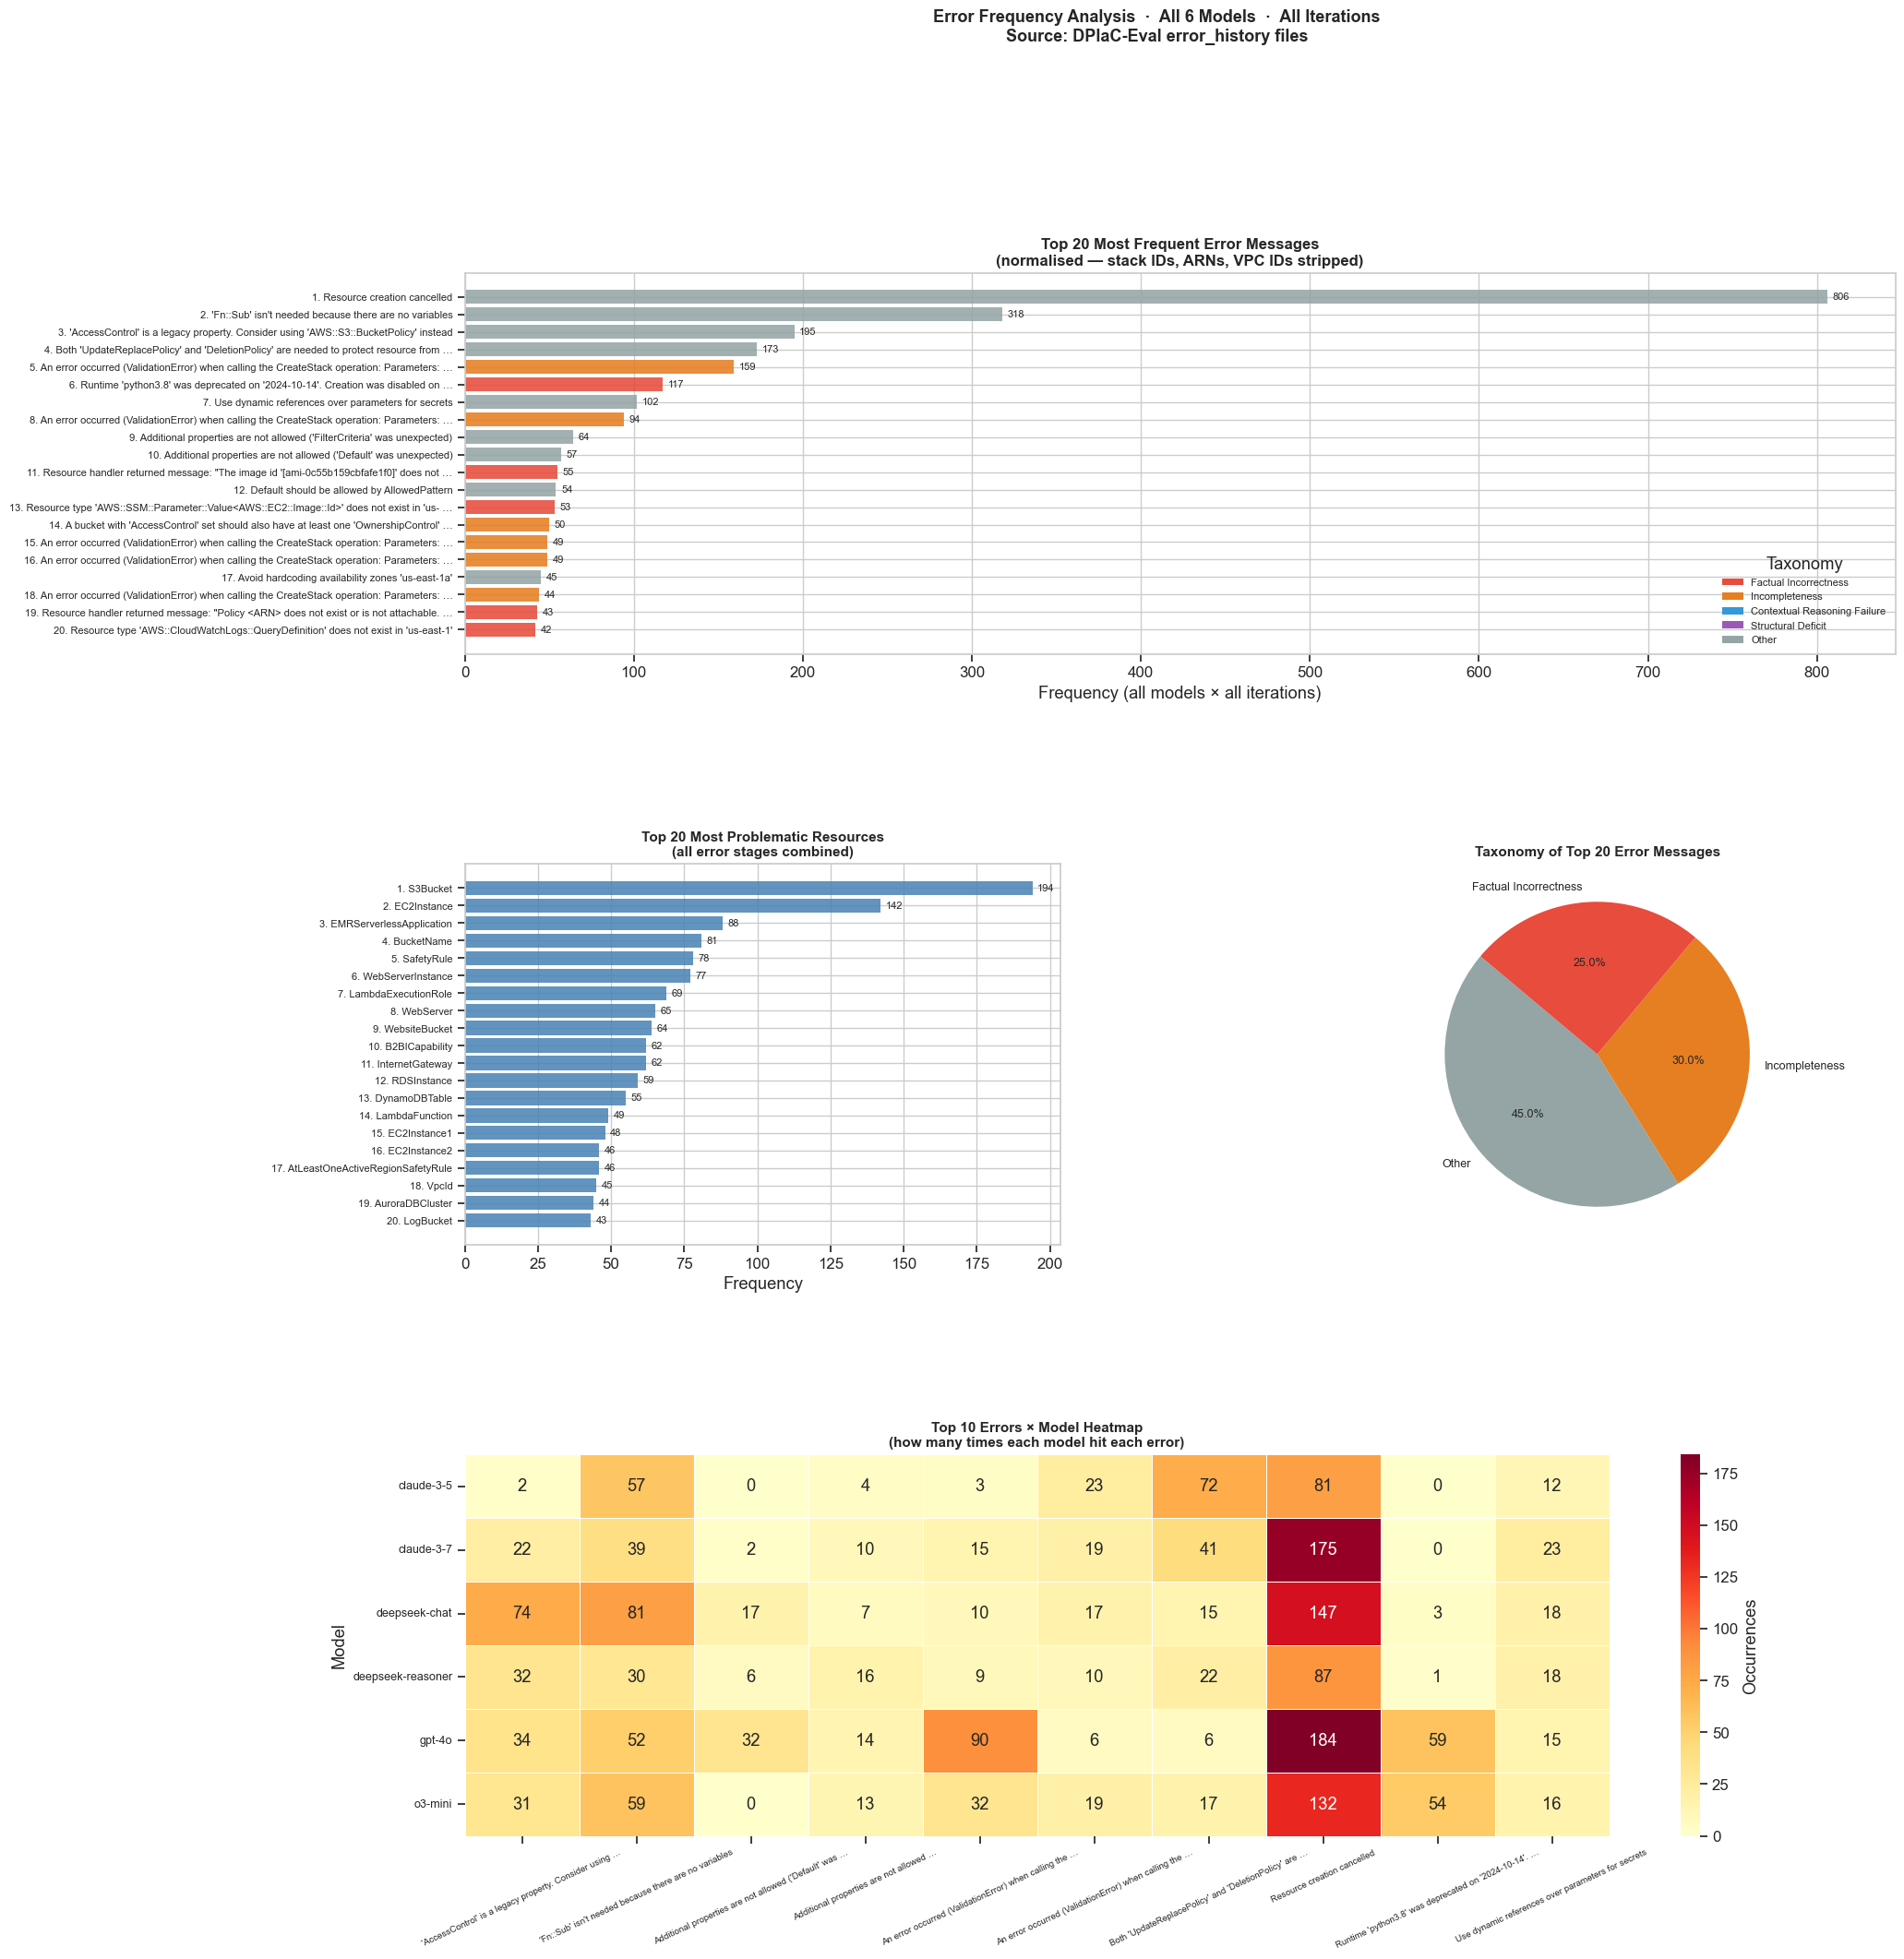

TOP 20 ERROR MESSAGES


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_92987/3931644983.py:165: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda t: f'color: {TAX_COLOURS.get(t, "black")}; font-weight: bold',


,frequency,taxonomy,error_message (truncated)
rank,,,
1,806,Other,Resource creation cancelled
2,318,Other,'Fn::Sub' isn't needed because there are no variables
3,195,Other,'AccessControl' is a legacy property. Consider using 'AWS::S3::BucketPolicy' instead
4,173,Other,Both 'UpdateReplacePolicy' and 'DeletionPolicy' are needed to protect resource from …
5,159,Incompleteness,An error occurred (ValidationError) when calling the CreateStack operation: Parameters: …
6,117,Factual Incorrectness,Runtime 'python3.8' was deprecated on '2024-10-14'. Creation was disabled on …
7,102,Other,Use dynamic references over parameters for secrets
8,94,Incompleteness,An error occurred (ValidationError) when calling the CreateStack operation: Parameters: …
9,64,Other,Additional properties are not allowed ('FilterCriteria' was unexpected)




TOP 20 MOST PROBLEMATIC RESOURCES


,resource,frequency
rank,,
1,S3Bucket,194
2,EC2Instance,142
3,EMRServerlessApplication,88
4,BucketName,81
5,SafetyRule,78
6,WebServerInstance,77
7,LambdaExecutionRole,69
8,WebServer,65
9,WebsiteBucket,64


In [111]:
# =============================================================================
# SECTION 11 – Top 20 Error Messages & Resources by Frequency
# =============================================================================

import textwrap

pd.set_option('display.max_colwidth', None)

# ── Helper: truncate long messages for display ────────────────────────────────
def truncate(msg, width=90):
    return textwrap.shorten(str(msg), width=width, placeholder=' …')

# ── 1. Normalise error messages (strip stack-specific IDs & ARNs) ─────────────
def normalise_msg(msg):
    msg = str(msg)
    # Remove ARNs
    msg = re.sub(r'arn:[^\s\'"]+', '<ARN>', msg)
    # Remove hex stack suffixes  e.g.  validation-stack-bbf87b20-bucket-uduyyl402gtk
    msg = re.sub(r'validation-stack-[a-z0-9\-]+', '<STACK>', msg)
    # Remove Request IDs
    msg = re.sub(r'RequestToken:[^\)]+', 'RequestToken:<ID>', msg)
    msg = re.sub(r'Request ID:[^\)]+',   'Request ID:<ID>',   msg)
    # Remove dynamic IP / VPC / subnet IDs
    msg = re.sub(r"'vpc-[a-z0-9]+'",    "'<VPC_ID>'",   msg)
    msg = re.sub(r"'subnet-[a-z0-9]+'", "'<SUBNET_ID>'", msg)
    msg = re.sub(r"'sg-[a-z0-9]+'",     "'<SG_ID>'",    msg)
    return msg.strip()

history_df['norm_message'] = history_df['error_message'].apply(normalise_msg)

# ── 2. Top 20 Error Messages ──────────────────────────────────────────────────
top_errors = (
    history_df['norm_message']
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'norm_message': 'error_message', 'count': 'frequency'})
)
top_errors['taxonomy'] = top_errors['error_message'].apply(classify_error)
top_errors['rank']     = range(1, 21)
top_errors['error_short'] = top_errors['error_message'].apply(lambda x: truncate(x, 90))

# ── 3. Top 20 Resources ───────────────────────────────────────────────────────
top_resources = (
    history_df['resource_name']
    .dropna()
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'resource_name': 'resource', 'count': 'frequency'})
)
top_resources['rank'] = range(1, 21)

# ── 4. Per-model error frequency (top 10 errors across models) ───────────────
top10_msgs = top_errors['error_message'].head(10).tolist()
model_error_heat = (
    history_df[history_df['norm_message'].isin(top10_msgs)]
    .groupby(['model_key', 'norm_message'])
    .size()
    .unstack(fill_value=0)
)
# Shorten column labels for heatmap
model_error_heat.columns = [truncate(c, 55) for c in model_error_heat.columns]

# ── 5. PLOT ───────────────────────────────────────────────────────────────────
TAX_COLOURS = {
    'Factual Incorrectness': '#e74c3c',
    'Incompleteness':        '#e67e22',
    'Contextual Reasoning Failure':  '#3498db',
    'Structural Deficit':    '#9b59b6',
    'Other':                 '#95a5a6',
}

fig = plt.figure(figsize=(20, 22))
gs  = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.4)

# ── Panel A: Top 20 Error Messages horizontal bar ────────────────────────────
ax_a = fig.add_subplot(gs[0, :])
colours_a = [TAX_COLOURS[t] for t in top_errors['taxonomy']]
bars_a = ax_a.barh(
    top_errors['rank'].astype(str) + '. ' + top_errors['error_short'],
    top_errors['frequency'],
    color=colours_a, alpha=0.88
)
ax_a.invert_yaxis()
ax_a.set_xlabel('Frequency (all models × all iterations)')
ax_a.set_title('Top 20 Most Frequent Error Messages\n(normalised — stack IDs, ARNs, VPC IDs stripped)',
               fontsize=12, fontweight='bold')
for bar in bars_a:
    ax_a.annotate(f'{int(bar.get_width())}',
                  xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                  xytext=(4, 0), textcoords='offset points',
                  va='center', fontsize=8)
# Taxonomy legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in TAX_COLOURS.items()]
ax_a.legend(handles=legend_elements, loc='lower right', fontsize=8, title='Taxonomy')
ax_a.tick_params(axis='y', labelsize=8)

# ── Panel B: Top 20 Resources horizontal bar ─────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
ax_b.barh(
    top_resources['rank'].astype(str) + '. ' + top_resources['resource'],
    top_resources['frequency'],
    color='steelblue', alpha=0.85
)
ax_b.invert_yaxis()
ax_b.set_xlabel('Frequency')
ax_b.set_title('Top 20 Most Problematic Resources\n(all error stages combined)', fontsize=11, fontweight='bold')
for bar in ax_b.patches:
    ax_b.annotate(f'{int(bar.get_width())}',
                  xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                  xytext=(4, 0), textcoords='offset points',
                  va='center', fontsize=8)
ax_b.tick_params(axis='y', labelsize=8)

# ── Panel C: Error taxonomy breakdown of top 20 errors ───────────────────────
ax_c = fig.add_subplot(gs[1, 1])
tax_counts = top_errors['taxonomy'].value_counts()
ax_c.pie(
    tax_counts,
    labels=tax_counts.index,
    autopct='%1.1f%%',
    colors=[TAX_COLOURS[t] for t in tax_counts.index],
    startangle=140,
    textprops={'fontsize': 9}
)
ax_c.set_title('Taxonomy of Top 20 Error Messages', fontsize=11, fontweight='bold')

# ── Panel D: Per-model heatmap of top 10 errors ───────────────────────────────
ax_d = fig.add_subplot(gs[2, :])
sns.heatmap(
    model_error_heat,
    ax=ax_d,
    annot=True, fmt='d',
    cmap='YlOrRd',
    linewidths=0.4,
    cbar_kws={'label': 'Occurrences'}
)
ax_d.set_title('Top 10 Errors × Model Heatmap\n(how many times each model hit each error)',
               fontsize=11, fontweight='bold')
ax_d.set_xlabel('')
ax_d.set_ylabel('Model')
ax_d.tick_params(axis='x', labelsize=7, rotation=25)
ax_d.tick_params(axis='y', labelsize=9, rotation=0)

plt.suptitle(
    'Error Frequency Analysis  ·  All 6 Models  ·  All Iterations\n'
    'Source: DPIaC-Eval error_history files',
    fontsize=13, y=1.01, fontweight='bold'
)
plt.savefig('plots/Error_Frequency_Analysis.png')
plt.show()

# ── 6. Display clean tables ───────────────────────────────────────────────────
print("=" * 100)
print("TOP 20 ERROR MESSAGES")
print("=" * 100)
display(
    top_errors[['rank', 'frequency', 'taxonomy', 'error_short']]
    .rename(columns={'error_short': 'error_message (truncated)'})
    .set_index('rank')
    .style
    .background_gradient(subset=['frequency'], cmap='Reds')
    .applymap(lambda t: f'color: {TAX_COLOURS.get(t, "black")}; font-weight: bold',
              subset=['taxonomy'])
)

print("\n")
print("=" * 60)
print("TOP 20 MOST PROBLEMATIC RESOURCES")
print("=" * 60)
display(
    top_resources[['rank', 'resource', 'frequency']]
    .set_index('rank')
    .style
    .background_gradient(subset=['frequency'], cmap='Blues')
)


## 6. User Intent Pass Rate
User intent is evaluated via Checkov custom policies (`UIV_CUSTOM_ROW_*`). A row passes only when all checks succeed (`pass_user_intent == True`). Coverage and accuracy provide a continuous signal alongside the binary pass rate. Row numbers are linked to `results_df` to compare deployment success vs intent pass.


   Model  Intent Pass Rate (%)  Deploy+Intent Rate (%)  Avg Coverage (%)  Avg Accuracy (%)
baseline             31.372549               31.372549         80.809756         90.145865
     cot             14.000000               14.000000         31.281822         27.227537
     cgo             25.490196               25.490196         60.541797         66.805668


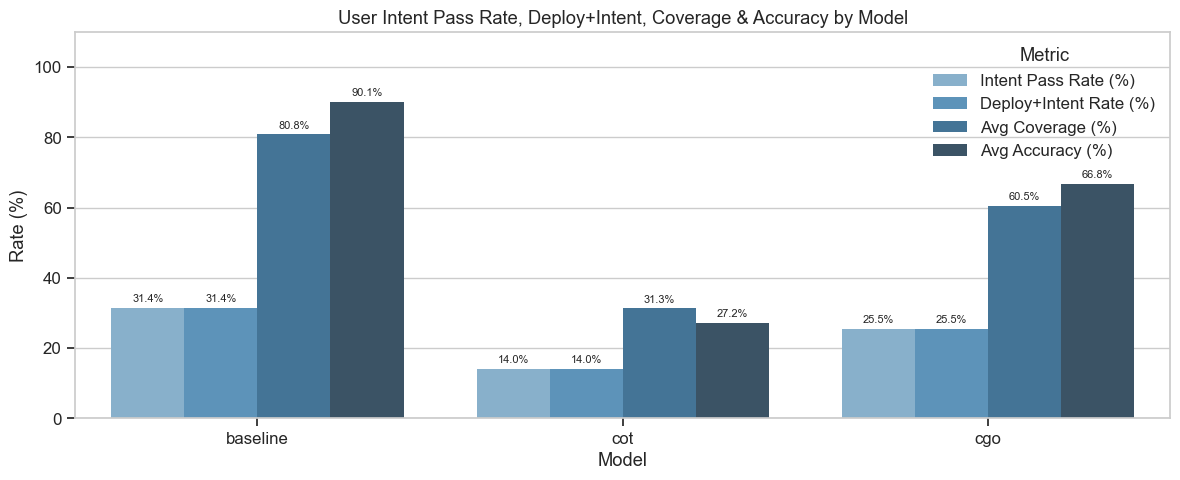

In [27]:
# --- 6a. User Intent Pass Rate per model_key ---
plt.figure(figsize=(12, 5))

intent_metrics = []
for model_key in intent_df['model_key'].unique():
    vdata = intent_df[intent_df['model_key'] == model_key]
    total = len(vdata)
    if total == 0:
        continue
    pass_count = vdata['pass_user_intent'].sum()

    # Link to results_df by row_number to find rows that also deployed successfully
    linked = results_df[results_df['row_number'].isin(vdata['row_number'])]
    deployed_rows = linked[linked['success'] == True]['row_number']
    deploy_and_intent = vdata[
        vdata['pass_user_intent'] & vdata['row_number'].isin(deployed_rows)
    ].shape[0]

    intent_metrics.append({
        'Model': model_key,
        'Intent Pass Rate (%)': (pass_count / total) * 100,
        'Deploy+Intent Rate (%)': (deploy_and_intent / total) * 100,
        'Avg Coverage (%)': vdata['coverage_percentage'].mean(),
        'Avg Accuracy (%)': vdata['accuracy_percentage'].mean(),
    })

intent_metrics_df = pd.DataFrame(intent_metrics)
print(intent_metrics_df.to_string(index=False))

melted = intent_metrics_df.melt(
    id_vars='Model',
    value_vars=['Intent Pass Rate (%)', 'Deploy+Intent Rate (%)', 'Avg Coverage (%)', 'Avg Accuracy (%)'],
    var_name='Metric', value_name='Rate (%)'
)

sns.barplot(data=melted, x='Model', y='Rate (%)', hue='Metric', palette='Blues_d')
plt.title('User Intent Pass Rate, Deploy+Intent, Coverage & Accuracy by Model')
plt.ylim(0, 110)
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f"{h:.1f}%",
                           (p.get_x() + p.get_width() / 2., h),
                           ha='center', va='bottom', fontsize=8,
                           xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig('plots/userintentpassrate.png', dpi=150, bbox_inches='tight')
plt.show()


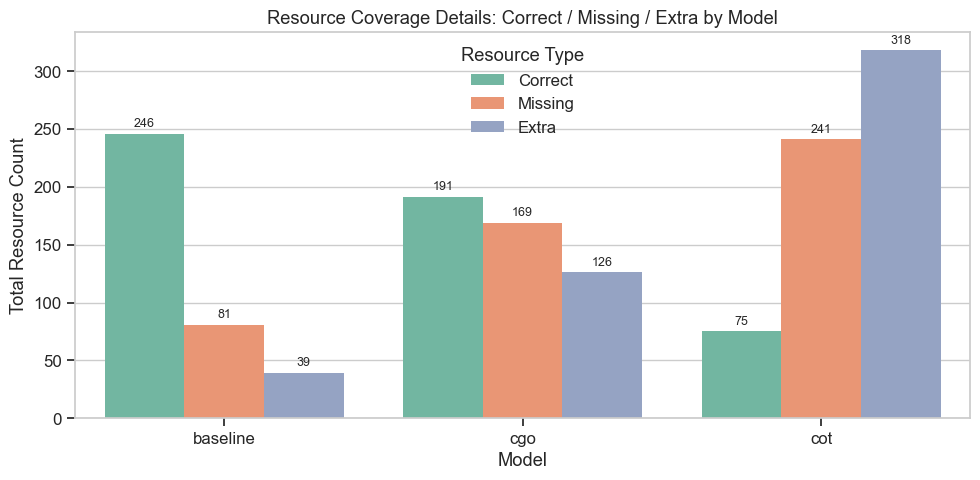

In [29]:
# --- 6b. Resource Details: correct vs missing vs extra per model_key ---
import ast

def parse_resource_details(val):
    try:
        if pd.isna(val) or val in ('', '{}', None):
            return 0, 0, 0
        d = ast.literal_eval(str(val))
        return len(d.get('correct', [])), len(d.get('missing', [])), len(d.get('extra', []))
    except Exception:
        return 0, 0, 0

intent_df[['n_correct', 'n_missing', 'n_extra']] = intent_df['resource_details'].apply(
    lambda v: pd.Series(parse_resource_details(v))
)

res_agg = intent_df.groupby('model_key')[['n_correct', 'n_missing', 'n_extra']].sum().reset_index()
res_agg = res_agg.melt(id_vars='model_key', var_name='Resource Type', value_name='Count')
res_agg['Resource Type'] = res_agg['Resource Type'].map({
    'n_correct': 'Correct', 'n_missing': 'Missing', 'n_extra': 'Extra'
})

plt.figure(figsize=(10, 5))
sns.barplot(data=res_agg, x='model_key', y='Count', hue='Resource Type', palette='Set2')
plt.title('Resource Coverage Details: Correct / Missing / Extra by Model')
plt.xlabel('Model')
plt.ylabel('Total Resource Count')
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f"{int(h)}",
                           (p.get_x() + p.get_width() / 2., h),
                           ha='center', va='bottom', fontsize=9,
                           xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig('plots/resourcecoveragedetails.png', dpi=150, bbox_inches='tight')  # ← before show()
plt.show()


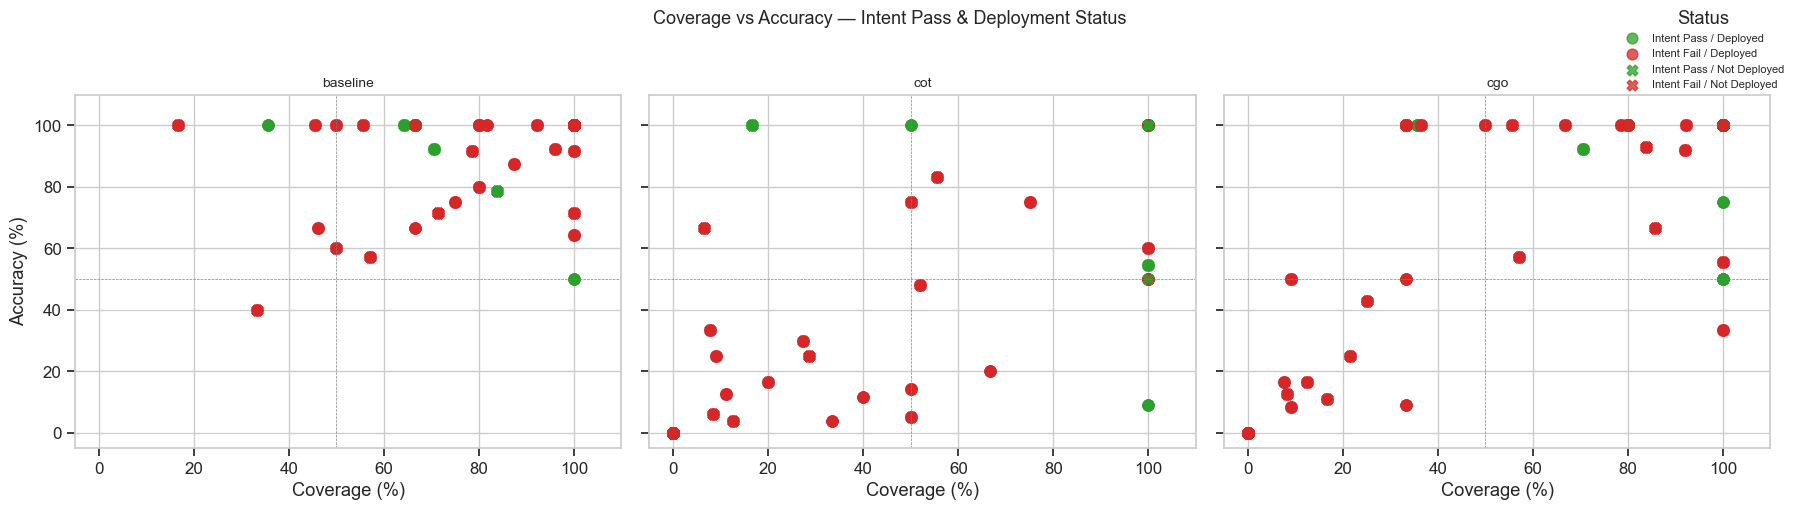

In [31]:
# --- 6c. Coverage vs Accuracy scatter, coloured by pass_user_intent, linked to results_df ---
model_keys = intent_df['model_key'].unique()
fig, axes = plt.subplots(1, len(model_keys), figsize=(6 * len(model_keys), 5), sharey=True)
if not hasattr(axes, '__iter__'):
    axes = [axes]

for ax, model_key in zip(axes, model_keys):
    vdata = intent_df[intent_df['model_key'] == model_key].copy()

    linked = results_df[
        results_df['row_number'].isin(vdata['row_number'])
    ][['row_number', 'success']].rename(columns={'success': 'deploy_success'})
    vdata = vdata.merge(linked, on='row_number', how='left')
    vdata['deploy_success'] = vdata['deploy_success'].fillna(False)

    for marker, deploy_label in [('o', 'Deployed'), ('X', 'Not Deployed')]:
        mask = vdata['deploy_success'] == (marker == 'o')
        for intent_pass, color, intent_label in [
            (True,  '#2ca02c', 'Intent Pass'),
            (False, '#d62728', 'Intent Fail'),
        ]:
            sub = vdata[mask & (vdata['pass_user_intent'] == intent_pass)]
            if not sub.empty:
                ax.scatter(
                    sub['coverage_percentage'], sub['accuracy_percentage'],
                    c=color, marker=marker, alpha=0.75, s=60,
                    label=f"{intent_label} / {deploy_label}"
                )

    ax.set_title(model_key, fontsize=10)
    ax.set_xlabel('Coverage (%)')
    ax.axhline(50, color='grey', lw=0.5, linestyle='--')
    ax.axvline(50, color='grey', lw=0.5, linestyle='--')
    ax.set_xlim(-5, 110)
    ax.set_ylim(-5, 110)

axes[0].set_ylabel('Accuracy (%)')
handles, labels = axes[-1].get_legend_handles_labels()
# deduplicate legend entries
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
fig.legend(seen.values(), seen.keys(), loc='upper right', fontsize=8, title='Status')
plt.suptitle('Coverage vs Accuracy — Intent Pass & Deployment Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/coveragevsaccuracy.png', dpi=150, bbox_inches='tight')  # ← before show()
plt.show()
